# MANIA v1.2 — 2026-06-17
# MANIA_analysis
> v1.2 - ДОБАВЛЕН ПРИОРИТЕТ ВЗАИМОДЕЙТСВИЙ И СОХРАНЕНИЕ TEMPORAL RIN

## Pipeline overview
```
Step 1.   Load & validate MANIA_preprocessing artefacts
Step 2.   Build consensus nx.Graph (per condition)
Step 3.   Graph QC
Step 4.   Global centrality metrics
Step 4b.  Regional subgraph analysis (ECD, epitope, TM)
Step 5.   Statistical tests (MWU, FDR-BH, Cohen d, Bootstrap CI)
Step 6.   Community detection (Louvain, NMI, ARI, Fisher enrichment)
Step 7.   Allosteric pathways
Step 8.   Protein-lipid / protein-glycan proximity
Step 9.   Temporal RIN + conformational state clustering (k-means)
Step 9b.  Temporal visualisation
Step 10.  Export WANIA-ready artefacts
```

## MANIA package architecture
```
MANIA
mania/io/               загрузка, валидация
mania/features/         признаки а.о.
mania/contacts/         контакты/кадр
mania/graph/            построение RIN
mania/metrics/          анализ графа
mania/metrics_by_window построение RIN по временным окнам
mania/clustering/       конформ. сост.
mania/export/           артефакты WANIA
```

> **Input (from MANIA_preprocessing):**
> `contacts_raw_{cond}.csv` + `residue_table_{cond}.csv` +
> `contacts_perframe_{cond}.parquet` + `metadata.json`



## Cell 1 -- Install dependencies

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
PACKAGES = ['yadisk','networkx>=3.0','scipy','statsmodels','scikit-learn','seaborn','matplotlib','pandas','numpy','tqdm','python-louvain']
if IN_COLAB:
    for pkg in PACKAGES:
        try:
            import importlib; importlib.import_module(pkg.split('>=')[0].replace('-','_'))
        except ImportError:
            import subprocess; subprocess.run([sys.executable,'-m','pip','install','-q',pkg],check=False)
print('Dependencies ready.')

Dependencies ready.


## Cell 2 -- Imports

In [ ]:
import json, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.family':'sans-serif','font.size':11,'axes.titlesize':12,'axes.labelsize':11,'figure.dpi':150})
print('Imports OK.')

Imports OK.


## Cell 3 -- Global parameters

In [ ]:
# MANIA: analysis config -- mirrors MANIAConfig from MANIA_preprocessing.
# In production: loaded from metadata.json.

EXPORT_DIR = Path('mania_output')   # <- MANIA_preprocessing output dir
OUT_DIR    = Path('mania_analysis_output')
FIG_DIR    = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Regions of interest -- adjust to your protein
REGIONS_OF_INTEREST = {
    'epitope':      (311, 341),
    'ECD':          (234, 361),
    'full_protein':  None,
}

CONDITIONS      = ['normal', 'tumor']
MIN_CONTACT_FREQ = 0.30
TEMP_WINDOW      = 10    # temporal: window width in frames
TEMP_STEP        = 10    # temporal: step between windows
TEMP_MIN_FREQ    = 0.25  # lower threshold within window
K_MAX            = 10     # max conformational states to test

print(f'EXPORT_DIR: {EXPORT_DIR}')
print(f'OUT_DIR   : {OUT_DIR}')

# ── Источник артефактов: 'local' | 'yadisk' ──────────────────────
SOURCE_ARTEFACTS = 'yadisk'  # 'local' — если EXPORT_DIR уже доступна локально

# Яндекс.Диск: токен и пути (используется при SOURCE_ARTEFACTS='yadisk')
# Токен берётся из Colab Secrets (ключ MW_TOKEN) или задаётся вручную.
MW_TOKEN  = ''           # ← оставь пустым при использовании Colab Secrets
YADISK_BASE   = 'MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/30ns_03-2026'
# Папка на Я.Диске, куда MANIA_preprocessing сохранял артефакты:
YADISK_INPUT_PATH  = f'disk:/{YADISK_BASE}/results/preprocess_export_v1.1'
# Папка для выгрузки результатов MANIA_analysis:
YADISK_OUTPUT_PATH = f'disk:/{YADISK_BASE}/results/analysis_export_v1.2'

EXPORT_DIR: mania_output
OUT_DIR   : mania_analysis_output


## Cell 3b — Загрузка артефактов MANIA_preprocessing

Скачивает файлы из папки `YADISK_INPUT_PATH` на Яндекс.Диске в локальную `EXPORT_DIR`.  
При `SOURCE_ARTEFACTS='local'` — шаг пропускается, файлы берутся из `EXPORT_DIR` как есть.

**Ожидаемые файлы:** `residue_table_*.csv`, `protein_contact_edges_undirected_*.csv`,
`nonprotein_nodes_*.csv`, `np_contact_edges_*.csv`, `contacts_perframe_*.parquet`,
`edge_semantics.json`, `phase3a_manifest.json`


In [ ]:
# MANIA: module io -> YaDiskLoader.download_artefacts()
# Package file: mania/io/yadisk_loader.py
#
# Скачивает артефакты MANIA_preprocessing с Яндекс.Диска в локальную EXPORT_DIR.
# При SOURCE_ARTEFACTS='local' — пропускается (файлы уже есть локально).

import time

def _resolve_yadisk_token():
    """Получить токен: сначала из MW_TOKEN, потом из Colab Secrets."""
    if MW_TOKEN:
        return MW_TOKEN
    try:
        from google.colab import userdata
        return userdata.get('MW_TOKEN')
    except Exception:
        raise ValueError(
            "MW_TOKEN не задан. "
            "Укажи его в cell-003 или добавь в Colab Secrets под ключом 'MW_TOKEN'."
        )

def _yadisk_download_file(client, remote_path, local_path):
    """Скачать один файл, если он ещё не закеширован."""
    if local_path.exists():
        print(f'  [cache] {local_path.name}')
        return
    local_path.parent.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    client.download(remote_path, str(local_path))
    size_mb = local_path.stat().st_size / 1024**2
    print(f'  [ok]    {local_path.name}  ({size_mb:.1f} MB, {time.time()-t0:.1f}s)')

def download_preprocessing_artefacts(token, remote_dir, local_dir):
    """Скачать все файлы из remote_dir -> local_dir."""
    import yadisk
    local_dir.mkdir(parents=True, exist_ok=True)
    with yadisk.Client(token=token) as client:
        if not client.check_token():
            raise ValueError("Токен Яндекс.Диска невалиден.")
        try:
            items = list(client.listdir(remote_dir))
        except Exception as e:
            raise RuntimeError(f"Не удалось прочитать папку {remote_dir}: {e}")
        print(f"Найдено файлов на Я.Диске ({remote_dir}): {len(items)}")
        for item in items:
            if item.type == 'file':
                local_path = local_dir / item.name
                _yadisk_download_file(client, item.path, local_path)
    print(f"Загрузка завершена → {local_dir}")

# ── Выполнение ──────────────────────────────────────────────────
if SOURCE_ARTEFACTS == 'yadisk':
    print(f"Загрузка артефактов с Яндекс.Диска: {YADISK_INPUT_PATH}")
    _token = _resolve_yadisk_token()
    download_preprocessing_artefacts(_token, YADISK_INPUT_PATH, EXPORT_DIR)
elif SOURCE_ARTEFACTS == 'local':
    print(f"SOURCE_ARTEFACTS='local' — используем локальную EXPORT_DIR: {EXPORT_DIR}")
    if not EXPORT_DIR.exists():
        raise FileNotFoundError(f"EXPORT_DIR не найдена: {EXPORT_DIR}")
    files = list(EXPORT_DIR.iterdir())
    print(f"  Файлов в EXPORT_DIR: {len(files)}")
else:
    raise ValueError(f"Неизвестный SOURCE_ARTEFACTS: {SOURCE_ARTEFACTS!r}. Допустимо: 'local', 'yadisk'")

# Показать доступные артефакты
available = sorted(p.name for p in EXPORT_DIR.iterdir() if p.is_file())
print(f"\nАртефакты MANIA_preprocessing ({len(available)}):")
for f in available:
    print(f'  {f}')

Загрузка артефактов с Яндекс.Диска: disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/30ns_03-2026/results/preprocess_export_v1.1
Найдено файлов на Я.Диске (disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/30ns_03-2026/results/preprocess_export_v1.1): 34
  [ok]    centrality_normal.csv  (0.1 MB, 2.2s)
  [ok]    centrality_tumor.csv  (0.1 MB, 1.5s)
  [ok]    communities_normal.csv  (0.0 MB, 1.3s)
  [ok]    communities_tumor.csv  (0.0 MB, 1.3s)
  [ok]    comparison.csv  (0.0 MB, 1.3s)
  [ok]    conformation_labels_normal.csv  (0.0 MB, 1.3s)
  [ok]    conformation_labels_tumor.csv  (0.0 MB, 1.3s)
  [ok]    conformation_pca_normal.csv  (0.0 MB, 1.4s)
  [ok]    conformation_pca_tumor.csv  (0.0 MB, 1.6s)
  [ok]    contacts_perframe_normal.parquet  (19.7 MB, 3.4s)
  [ok]    contacts_perframe_tumor.parquet  (19.8 MB, 3.1s)
  [ok]    edge_semantics.json  (0.0 MB, 1.1s)
  [ok]    graph.json  (1.3 MB, 1.8s)
  [ok]    mania_config.json  (0.0 MB, 1.5s)
  [ok]    mania_manifest.json  

## Cell 4 -- Load & validate artefacts

In [ ]:
# MANIA: module graph -> MANIAGraph.load()
# Validates: required columns, resid consistency, edge count.

EDGES:    Dict[str, pd.DataFrame] = {}
RESTABLE: Dict[str, pd.DataFrame] = {}

def assign_region(resid: int) -> str:
    """Возвращает первый подходящий регион (не full_protein)."""
    for name, bounds in REGIONS_OF_INTEREST.items():
        if bounds is None:
            continue
        start, end = bounds
        if start <= resid <= end:
            return name
    return 'other'

for cond in CONDITIONS:
    edges_path = EXPORT_DIR / f'protein_contact_edges_undirected_{cond}.csv'
    nodes_path = EXPORT_DIR / f'residue_table_{cond}.csv'
    if not edges_path.exists() or not nodes_path.exists():
        print(f'[{cond}] SKIP -- files not found (demo mode)')
        continue
    edges = pd.read_csv(edges_path)
    nodes = pd.read_csv(nodes_path)
    nodes['region'] = nodes['resid'].apply(assign_region)
    required_edges = {'resid_i', 'resid_j', 'edge_type', 'contact_freq', 'mean_dist_A', 'std_dist_A'}
    required_nodes = {'resid', 'resname'}
    missing_e = required_edges - set(edges.columns)
    missing_n = required_nodes - set(nodes.columns)
    if missing_e: raise ValueError(f'[{cond}] contacts_raw missing: {missing_e}')
    if missing_n: raise ValueError(f'[{cond}] residue_table missing: {missing_n}')
    edges = edges[edges['resid_i'] < edges['resid_j']].copy()
    EDGES[cond]    = edges
    RESTABLE[cond] = nodes
    print(f'[{cond}] {len(nodes)} residues | {len(edges)} edges | {edges["edge_type"].nunique()} edge types')

print('Load OK.')

[normal] 690 residues | 3482 edges | 7 edge types
[tumor] 690 residues | 3551 edges | 7 edge types
Load OK.


## Cell 5 -- Build nx.Graph

In [ ]:
# MANIA: module graph -> Build nx.Graph
# При конфликте типов на одной паре (i,j) приоритет: hbond > disulfide > salt_bridge >
# ionic > cation_pi > aromatic_pi > hydrophobic > vdw

EDGE_PRIORITY = ['hbond', 'disulfide', 'salt_bridge', 'ionic',
                 'cation_pi', 'aromatic_pi', 'hydrophobic', 'vdw']

GRAPHS: Dict[str, nx.Graph] = {}

for cond in CONDITIONS:
    if cond not in EDGES: continue
    G = nx.Graph()

    for _, row in RESTABLE[cond].iterrows():
        G.add_node(int(row['resid']), **row.to_dict())

    # группируем рёбра по паре (i, j)
    from collections import defaultdict
    edge_groups = defaultdict(list)
    for _, row in EDGES[cond].iterrows():
        key = (int(row['resid_i']), int(row['resid_j']))
        edge_groups[key].append(row)

    for (i, j), rows in edge_groups.items():
        # выбираем тип с наивысшим приоритетом
        types_present = [r['edge_type'] for r in rows]
        winner = next(
            (t for t in EDGE_PRIORITY if t in types_present),
            types_present[0]  # fallback: берём первый если тип не в списке
        )
        winner_row = next(r for r in rows if r['edge_type'] == winner)
        G.add_edge(i, j,
                   edge_type=str(winner_row['edge_type']),
                   contact_freq=float(winner_row['contact_freq']),
                   mean_dist_A=float(winner_row['mean_dist_A']),
                   std_dist_A=float(winner_row['std_dist_A']),
                   n_types=len(rows),
                   all_types='|'.join(sorted(set(types_present))))

    GRAPHS[cond] = G
    print(f'[{cond}] nx.Graph: {G.number_of_nodes()} nodes | {G.number_of_edges()} edges | density={nx.density(G):.4f}')

print('Graphs built.')

[normal] nx.Graph: 690 nodes | 3263 edges | density=0.0137
[tumor] nx.Graph: 690 nodes | 3331 edges | density=0.0140
Graphs built.


## Cell 6 -- Graph QC

In [ ]:
# MANIA: module graph -> GraphQC
# Checks: self-loops, isolated nodes, connected components, edge type counts.

for cond in CONDITIONS:
    if cond not in GRAPHS: continue
    G = GRAPHS[cond]
    issues = []
    self_loops = list(nx.selfloop_edges(G))
    if self_loops:
        issues.append(f'WARN: {len(self_loops)} self-loops removed')
        G.remove_edges_from(self_loops)
    isolated = list(nx.isolates(G))
    if isolated: issues.append(f'INFO: {len(isolated)} isolated nodes')
    n_cc = nx.number_connected_components(G)
    if n_cc > 1: issues.append(f'INFO: {n_cc} connected components')
    etypes = pd.Series([d['edge_type'] for _,_,d in G.edges(data=True)]).value_counts()
    status = 'OK' if not any('FAIL' in i for i in issues) else 'FAIL'
    print(f'[{cond}] QC {status}')
    for issue in issues: print(f'  {issue}')
    print(f'  edge types: {dict(etypes)}')

print('QC done.')

[normal] QC OK
  edge types: {'vdw': np.int64(3066), 'hydrophobic': np.int64(99), 'hbond': np.int64(58), 'aromatic_pi': np.int64(24), 'salt_bridge': np.int64(8), 'ionic': np.int64(6), 'cation_pi': np.int64(2)}
[tumor] QC OK
  edge types: {'vdw': np.int64(3134), 'hydrophobic': np.int64(98), 'hbond': np.int64(54), 'aromatic_pi': np.int64(26), 'salt_bridge': np.int64(11), 'ionic': np.int64(6), 'cation_pi': np.int64(2)}
QC done.


## Cell 7 -- Global centrality metrics

In [ ]:
# MANIA: module metrics -> CentralityCalc
# Package file: mania/metrics/centrality.py
# Metrics: degree, strength (weighted), betweenness, closeness,
#          eigenvector, pagerank, k-core
# Weight: contact_freq (higher = stronger connection)

METRICS    = ['degree','strength','betweenness','closeness','eigenvector','pagerank','kcore']
CENTRALITY: Dict[str, pd.DataFrame] = {}

for cond in CONDITIONS:
    if cond not in GRAPHS: continue
    G   = GRAPHS[cond]
    bet = nx.betweenness_centrality(G, weight='contact_freq', normalized=True)
    clo = nx.closeness_centrality(G)
    eig = nx.eigenvector_centrality_numpy(G, weight='contact_freq')
    pgr = nx.pagerank(G, weight='contact_freq')
    kcr = nx.core_number(G)
    deg = dict(G.degree())
    str_ = {n: sum(d.get('contact_freq',0) for _,_,d in G.edges(n,data=True)) for n in G.nodes()}
    df = pd.DataFrame({
        'resid':       list(G.nodes()),
        'degree':      [deg[n]  for n in G.nodes()],
        'strength':    [str_[n] for n in G.nodes()],
        'betweenness': [bet[n]  for n in G.nodes()],
        'closeness':   [clo[n]  for n in G.nodes()],
        'eigenvector': [eig[n]  for n in G.nodes()],
        'pagerank':    [pgr[n]  for n in G.nodes()],
        'kcore':       [kcr[n]  for n in G.nodes()],
    })
    df = df.merge(RESTABLE[cond][['resid','resname','region']], on='resid', how='left')
    CENTRALITY[cond] = df
    df.to_csv(OUT_DIR / f'centrality_{cond}.csv', index=False)
    print(f'[{cond}] centrality computed for {len(df)} residues')

print('Centrality done.')

[normal] centrality computed for 690 residues
[tumor] centrality computed for 690 residues
Centrality done.


## Cell 8 -- Community detection (Louvain)

In [ ]:
# MANIA: module community -> CommunityDetector
# Algorithm: Louvain (networkx 3.0+)
# Metrics: modularity Q, cross-condition NMI, ARI
# Enrichment: Fisher exact test for epitope/ECD per community

import networkx.algorithms.community as nxcomm

PARTITIONS:  Dict[str, Dict] = {}
MODULARITY:  Dict[str, float] = {}
COMMUNITIES: Dict[str, Dict]  = {}

for cond in CONDITIONS:
    if cond not in GRAPHS: continue
    G = GRAPHS[cond]
    communities = nxcomm.louvain_communities(G, weight='contact_freq', seed=42)
    partition   = {r: cid for cid, members in enumerate(communities) for r in members}
    Q           = nxcomm.modularity(G, communities, weight='contact_freq')
    comm_map    = {cid: list(members) for cid, members in enumerate(communities)}
    PARTITIONS[cond]  = partition
    MODULARITY[cond]  = Q
    COMMUNITIES[cond] = comm_map
    print(f'[{cond}] Q={Q:.4f} | n_communities={len(comm_map)} | largest={max(len(v) for v in comm_map.values())} residues')
    CENTRALITY[cond]['community'] = CENTRALITY[cond]['resid'].map(partition).fillna(-1).astype(int)

if len(CONDITIONS) >= 2 and all(c in PARTITIONS for c in CONDITIONS[:2]):
    c1, c2  = CONDITIONS[0], CONDITIONS[1]
    shared  = sorted(set(PARTITIONS[c1]) & set(PARTITIONS[c2]))
    l1      = [PARTITIONS[c1][r] for r in shared]
    l2      = [PARTITIONS[c2][r] for r in shared]
    print(f'Cross-condition NMI={normalized_mutual_info_score(l1,l2):.4f} | ARI={adjusted_rand_score(l1,l2):.4f}')

print('Community detection done.')

[normal] Q=0.8394 | n_communities=18 | largest=63 residues
[tumor] Q=0.8356 | n_communities=18 | largest=64 residues
Cross-condition NMI=0.8392 | ARI=0.6762
Community detection done.


## Cell 9 -- Statistical tests (MWU, FDR-BH, Cohen d, Bootstrap CI)

In [ ]:
# MANIA: module stats -> StatsEngine
# Comparisons per metric: epitope vs other, ECD vs other
# Tests: Mann-Whitney U -> FDR-BH
# Effect size: Cohen d  |  Uncertainty: Bootstrap 95% CI

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2: return 0.0
    s = np.sqrt(((n1-1)*np.var(a,ddof=1)+(n2-1)*np.var(b,ddof=1))/(n1+n2-2))
    return (np.mean(a)-np.mean(b))/s if s > 1e-12 else 0.0

def bootstrap_ci(values, n_boot=1000, ci=0.95):
    if len(values) < 2: return float(np.mean(values)), float(np.mean(values)), float(np.mean(values))
    means = [np.mean(np.random.choice(values,len(values),replace=True)) for _ in range(n_boot)]
    return float(np.mean(values)), float(np.percentile(means,(1-ci)/2*100)), float(np.percentile(means,(1+ci)/2*100))

np.random.seed(42)
STAT_ROWS = []

def range_to_set(b): return set(range(int(b[0]),int(b[1])+1)) if b else set()

EPITOPE_RESIDS = range_to_set(REGIONS_OF_INTEREST['epitope'])
ECD_RESIDS_ALL = range_to_set(REGIONS_OF_INTEREST['ECD'])

for metric in METRICS:
    for cond in CONDITIONS:
        if cond not in CENTRALITY: continue
        df = CENTRALITY[cond]
        groups = {
            'epitope': df[df['resid'].isin(EPITOPE_RESIDS)][metric].dropna().values,
            'ECD_all': df[df['resid'].isin(ECD_RESIDS_ALL)][metric].dropna().values,
            'other':   df[~df['resid'].isin(ECD_RESIDS_ALL)][metric].dropna().values,
        }
        for g1, g2, label in [('epitope','other','epitope vs other'),('ECD_all','other','ECDep vs other')]:
            a, b = groups[g1], groups[g2]
            if len(a)<2 or len(b)<2: continue
            _, pval = mannwhitneyu(a, b, alternative='two-sided')
            cd = cohens_d(a, b)
            ma, lo_a, hi_a = bootstrap_ci(a)
            mb, lo_b, hi_b = bootstrap_ci(b)
            STAT_ROWS.append({'condition':cond,'metric':metric,'comparison':label,
                              'U_pval':pval,'cohens_d':round(cd,4),
                              'mean_g1':round(ma,6),'CI95_lo_g1':round(lo_a,6),'CI95_hi_g1':round(hi_a,6),
                              'mean_g2':round(mb,6),'CI95_lo_g2':round(lo_b,6),'CI95_hi_g2':round(hi_b,6)})

STAT_DF = pd.DataFrame(STAT_ROWS)
if len(STAT_DF):
    _, padj, _, _ = multipletests(STAT_DF['U_pval'].fillna(1.0), method='fdr_bh')
    STAT_DF['FDR'] = padj
    STAT_DF['sig'] = STAT_DF['FDR'].apply(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
    STAT_DF.to_csv(OUT_DIR/'stats.csv', index=False)
    sig = STAT_DF[STAT_DF['FDR']<0.05]
    print(f'Significant comparisons (FDR<0.05): {len(sig)}')
    if len(sig): print(sig[['condition','metric','comparison','cohens_d','FDR','sig']].to_string(index=False))
else:
    print('No data (check CENTRALITY).')

print('Stats done.')


Significant comparisons (FDR<0.05): 19
condition      metric       comparison  cohens_d          FDR sig
   normal      degree epitope vs other   -0.5779 3.184430e-03  **
   normal      degree   ECDep vs other   -0.3358 1.042275e-03  **
    tumor      degree epitope vs other   -0.4271 2.646433e-02   *
    tumor      degree   ECDep vs other   -0.2575 1.246566e-02   *
   normal    strength epitope vs other   -0.5255 2.445092e-03  **
   normal    strength   ECDep vs other   -0.2961 1.216304e-03  **
    tumor    strength epitope vs other   -0.5659 1.216304e-03  **
    tumor    strength   ECDep vs other   -0.2605 3.115287e-03  **
   normal   closeness epitope vs other   -2.6700 1.579906e-19 ***
   normal   closeness   ECDep vs other   -0.9976 1.362502e-19 ***
    tumor   closeness epitope vs other   -2.0548 6.284079e-16 ***
    tumor   closeness   ECDep vs other   -0.7615 6.284079e-16 ***
   normal eigenvector epitope vs other   -0.7132 2.068713e-14 ***
   normal eigenvector   ECDep vs othe

## Cell 10 -- Temporal RIN (sliding window)

In [ ]:
# MANIA: module temporal -> TemporalRIN
# Reads contacts_perframe_{cond}.parquet from MANIA_preprocessing Cell 7.
# For each sliding window computes: nnodes, nedges, density, mean_degree,
#   modularity, n_communities, betweenness_mean/max, closeness_mean, strength_mean
#
# User limits (WANIA blocks):
#   * n_windows = min(windows, CFG.max_snapshots)
#   * n_residues > 1000 -> temporal animation disabled in WANIA

PERFRAME: Dict[str, pd.DataFrame] = {}
for cond in CONDITIONS:
    p = EXPORT_DIR / f'contacts_perframe_{cond}.parquet'
    if p.exists():
        PERFRAME[cond] = pd.read_parquet(p)
        print(f'[{cond}] loaded {len(PERFRAME[cond])} rows | {PERFRAME[cond]["frame"].nunique()} frames')
    else:
        print(f'[{cond}] WARN: {p.name} not found. Run MANIA_preprocessing Cell 7 first.')

def build_window_graph(subset, n_frames, min_freq):
    if subset.empty: return nx.Graph()
    freq = (subset.groupby(['resid_i','resid_j']).size().div(n_frames).reset_index(name='contact_freq'))
    freq = freq[freq['contact_freq'] >= min_freq]
    G    = nx.Graph()
    for _, row in freq.iterrows():
        G.add_edge(int(row['resid_i']), int(row['resid_j']), contact_freq=float(row['contact_freq']))
    return G

def graph_metrics_window(G):
    if G.number_of_nodes() == 0:
        return {k: np.nan for k in ['nnodes','nedges','density','mean_degree','modularity','n_communities','betweenness_mean','betweenness_max','closeness_mean','strength_mean']}
    bet = nx.betweenness_centrality(G, weight='contact_freq', normalized=True)
    clo = nx.closeness_centrality(G)
    deg = dict(G.degree())
    str_ = {n: sum(d.get('contact_freq',0) for _,_,d in G.edges(n,data=True)) for n in G.nodes()}
    try:
        comms = nxcomm.louvain_communities(G, weight='contact_freq', seed=42)
        Q     = nxcomm.modularity(G, comms, weight='contact_freq')
        ncom  = len(comms)
    except Exception:
        Q, ncom = np.nan, np.nan
    return {'nnodes':G.number_of_nodes(),'nedges':G.number_of_edges(),'density':nx.density(G),
            'mean_degree':np.mean(list(deg.values())),'modularity':Q,'n_communities':ncom,
            'betweenness_mean':np.mean(list(bet.values())),'betweenness_max':np.max(list(bet.values())),
            'closeness_mean':np.mean(list(clo.values())),'strength_mean':np.mean(list(str_.values()))}

TEMPORAL_RESULTS: Dict[str, pd.DataFrame] = {}
for cond, pfdf in PERFRAME.items():
    all_frames = sorted(pfdf['frame'].unique())
    n_total    = len(all_frames)
    rows = []
    if n_total < TEMP_WINDOW:
        print(f'[{cond}] only {n_total} frames < TEMP_WINDOW={TEMP_WINDOW}, skipping.')
        continue
    starts = range(0, n_total - TEMP_WINDOW + 1, TEMP_STEP)
    for s in tqdm(starts, desc=f'{cond} windows'):
        win_frames = all_frames[s: s + TEMP_WINDOW]
        subset     = pfdf[pfdf['frame'].isin(win_frames)]
        m          = graph_metrics_window(build_window_graph(subset, len(win_frames), TEMP_MIN_FREQ))
        m.update({'frame_start':win_frames[0],'frame_end':win_frames[-1],
                  'frame_mid':win_frames[len(win_frames)//2],'cond':cond})
        rows.append(m)
    TEMPORAL_RESULTS[cond] = pd.DataFrame(rows)
    TEMPORAL_RESULTS[cond].to_csv(OUT_DIR / f'temporal_rin_{cond}.csv', index=False)
    print(f'[{cond}] {len(rows)} windows done')

print('Temporal RIN done.')

[normal] loaded 7206641 rows | 301 frames
[tumor] loaded 7245547 rows | 301 frames


normal windows:   0%|          | 0/30 [00:00<?, ?it/s]

[normal] 30 windows done


tumor windows:   0%|          | 0/30 [00:00<?, ?it/s]

[tumor] 30 windows done
Temporal RIN done.


## Cell 11 -- Conformational state clustering (NEW)

Кластеризация конформационных состояний по бинарным фингерпринтам контактов:
- каждый кадр = бинарный вектор (contacting pairs)
- PCA -> k-means (k=2..K_MAX)
- выбор k: максимальный силуэт
- репрезентативные кадры = ближайшие к центроиду в PCA-пространстве

**Применение:**
- Сценарий 1/2: есть ли несколько конформаций?
- Сценарий 3 (steered MD + лиганд): состояния = стадии пути связывания

[normal] PCA: 10 components -> 29.2% variance
[normal] Best k=5 (silhouette=0.387)
  Representative frames: {0: np.int32(2830), 1: np.int32(990), 2: np.int32(280), 3: np.int32(2060), 4: np.int32(1580)}


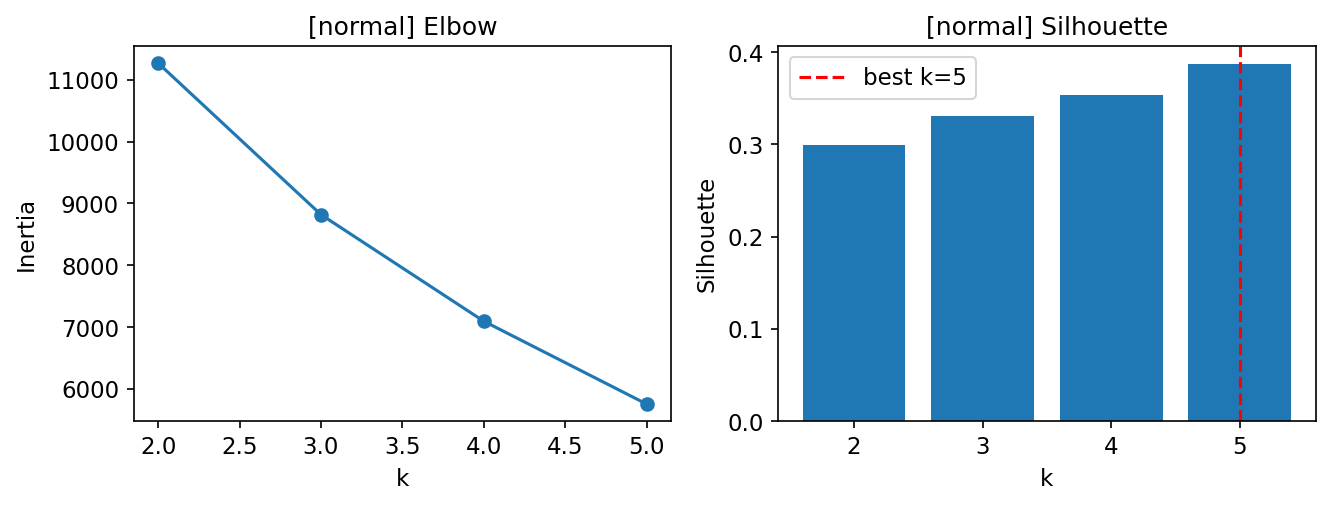

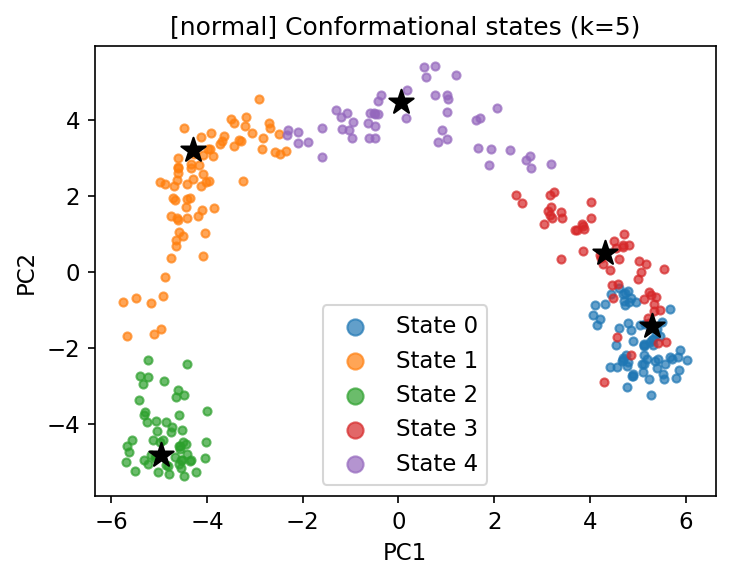

[tumor] PCA: 10 components -> 33.0% variance
[tumor] Best k=5 (silhouette=0.390)
  Representative frames: {0: np.int32(1340), 1: np.int32(1990), 2: np.int32(690), 3: np.int32(2810), 4: np.int32(180)}


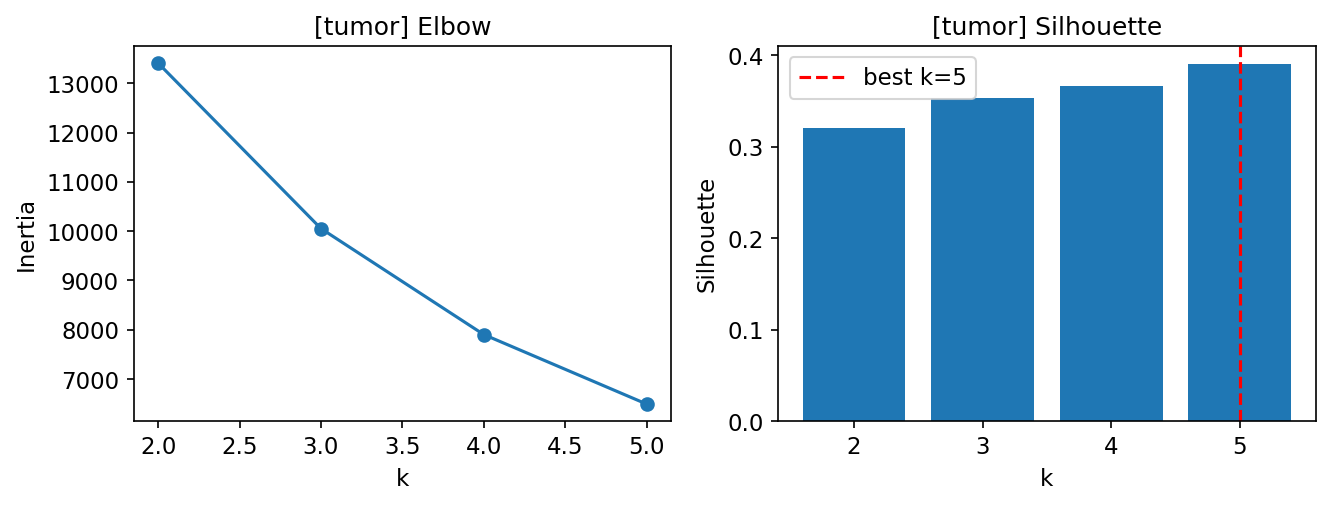

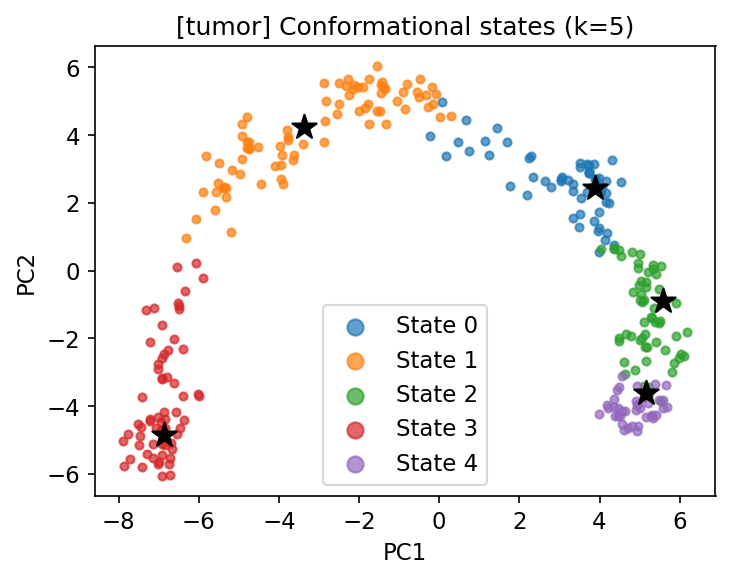

Conformational clustering done.


In [ ]:
# MANIA: module temporal -> ConformationalClustering
# Package file: mania/temporal/conformation.py
#
# Algorithm:
#   1. Binary contact fingerprint per frame (N_pairs vector, 0/1)
#   2. PCA (up to 10 components)
#   3. k-means, k in {2..K_MAX}
#   4. Best k: max silhouette score
#   5. Representative frames: closest to centroid in PCA space
# Export: conformation_labels_{cond}.csv, conformation_pca_{cond}.csv

CONFORMATION_LABELS: Dict[str, pd.DataFrame] = {}

for cond, pfdf in PERFRAME.items():
    frames     = sorted(pfdf['frame'].unique())
    n_frames_pf = len(frames)
    if n_frames_pf < 4:
        print(f'[{cond}] too few frames ({n_frames_pf}), skip.')
        continue

    # -- 1. Binary contact fingerprint --
    all_pairs   = sorted(set(zip(pfdf['resid_i'].astype(int), pfdf['resid_j'].astype(int))))
    pair_index  = {p: i for i, p in enumerate(all_pairs)}
    frame_index = {f: i for i, f in enumerate(frames)}
    fingerprints = np.zeros((n_frames_pf, len(all_pairs)), dtype=np.float32)
    for _, row in pfdf.iterrows():
        fi = frame_index[int(row['frame'])]
        pi = pair_index.get((int(row['resid_i']), int(row['resid_j'])))
        if pi is not None: fingerprints[fi, pi] = 1.0

    # -- 2. PCA --
    scaler   = StandardScaler(with_std=False)
    fp_c     = scaler.fit_transform(fingerprints)
    n_comp   = min(10, n_frames_pf - 1, len(all_pairs) - 1)
    pca      = PCA(n_components=n_comp, random_state=42)
    fp_pca   = pca.fit_transform(fp_c)
    var_expl = pca.explained_variance_ratio_.cumsum()
    print(f'[{cond}] PCA: {n_comp} components -> {var_expl[-1]*100:.1f}% variance')

    # -- 3-4. k-means + silhouette --
    k_range     = range(2, min(K_MAX + 1, n_frames_pf))
    inertias    = []
    silhouettes = []
    for k in k_range:
        km_k     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_k = km_k.fit_predict(fp_pca)
        inertias.append(km_k.inertia_)
        silhouettes.append(silhouette_score(fp_pca, labels_k) if len(set(labels_k)) > 1 else -1)

    best_k = list(k_range)[int(np.argmax(silhouettes))]
    print(f'[{cond}] Best k={best_k} (silhouette={max(silhouettes):.3f})')

    km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    state_labels = km_best.fit_predict(fp_pca)

    # -- 5. Representative frames --
    centroids  = km_best.cluster_centers_
    rep_frames = {}
    for k_id in range(best_k):
        mask  = state_labels == k_id
        dists = np.linalg.norm(fp_pca[mask] - centroids[k_id], axis=1)
        idx   = np.where(mask)[0][np.argmin(dists)]
        rep_frames[k_id] = frames[idx]
    print(f'  Representative frames: {rep_frames}')

    # -- 6. Export --
    df_labels = pd.DataFrame({
        'frame':    frames,
        'state':    state_labels,
        'is_repr':  [int(frames[i] == rep_frames.get(state_labels[i], -1)) for i in range(n_frames_pf)],
    })
    n_vis = min(3, fp_pca.shape[1])
    df_pca_exp = pd.DataFrame(fp_pca[:, :n_vis], columns=[f'PC{i+1}' for i in range(n_vis)])
    df_pca_exp['frame'] = frames
    df_pca_exp['state'] = state_labels
    df_labels.to_csv(OUT_DIR / f'conformation_labels_{cond}.csv', index=False)
    df_pca_exp.to_csv(OUT_DIR / f'conformation_pca_{cond}.csv', index=False)
    CONFORMATION_LABELS[cond] = df_labels

    # -- Plots --
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].plot(list(k_range), inertias, 'o-')
    axes[0].set(xlabel='k', ylabel='Inertia', title=f'[{cond}] Elbow')
    axes[1].bar(list(k_range), silhouettes)
    axes[1].axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
    axes[1].set(xlabel='k', ylabel='Silhouette', title=f'[{cond}] Silhouette')
    axes[1].legend(); plt.tight_layout()
    plt.savefig(FIG_DIR / f'conformation_clustering_{cond}.png', dpi=200, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    for k_id in range(best_k):
        mask = state_labels == k_id
        ax.scatter(fp_pca[mask, 0], fp_pca[mask, 1], label=f'State {k_id}', s=15, alpha=0.7)
        rf = rep_frames[k_id]; ri = frames.index(rf)
        ax.scatter(fp_pca[ri, 0], fp_pca[ri, 1], marker='*', s=150, color='black', zorder=5)
    ax.set(xlabel='PC1', ylabel='PC2', title=f'[{cond}] Conformational states (k={best_k})')
    ax.legend(markerscale=2); plt.tight_layout()
    plt.savefig(FIG_DIR / f'conformation_pca_{cond}.png', dpi=200, bbox_inches='tight')
    plt.show()

print('Conformational clustering done.')

## Cell 12 -- Export WANIA-ready artefacts

In [ ]:
# MANIA: module export -> MANIAExporter.export_wania_bundle()
# Package file: mania/export/wania.py
#
# WANIA reads these files via REST API:
#   graph.json                      -- Cytoscape.js compatible nodes+edges
#   metrics_{cond}.csv              -- centrality, community, region
#   communities_{cond}.csv          -- community composition
#   comparison.csv                  -- statistical comparison results
#   temporal_rin_{cond}.csv         -- sliding-window topology
#   conformation_labels_{cond}.csv  -- conformational state per frame
#   conformation_pca_{cond}.csv     -- PCA coordinates per frame
#
# graph.json format (Cytoscape.js):
# { 'elements': { 'nodes': [...], 'edges': [...] } }

wania_nodes = []
wania_edges = []

for cond in CONDITIONS:
    if cond not in CENTRALITY or cond not in EDGES:
        continue

    # ── Nodes ──────────────────────────────────────────────────────────────
    for _, row in CENTRALITY[cond].iterrows():
        node_data = row.to_dict()
        node_data['id']        = str(int(row['resid']))
        node_data['condition'] = cond
        # сериализация: numpy-типы → Python native
        node_data = {k: (v.item() if hasattr(v, 'item') else v)
                     for k, v in node_data.items()}
        wania_nodes.append({'data': node_data})

    # ── Edges ───────────────────────────────────────────────────────────────
    # Реальные имена колонок из cell-004: resid_i, resid_j, edge_type,
    #   contact_freq, mean_dist_A
    edge_df = EDGES[cond]
    for _, row in edge_df.iterrows():
        wania_edges.append({'data': {
            'source':       str(int(row['resid_i'])),
            'target':       str(int(row['resid_j'])),
            'edge_type':    row['edge_type'],
            'contact_freq': float(row['contact_freq']),
            'mean_dist_A':  float(row['mean_dist_A']),
            'condition':    cond,
        }})

graph_bundle = {'elements': {'nodes': wania_nodes, 'edges': wania_edges}}
with open(OUT_DIR / 'graph.json', 'w') as f:
    json.dump(graph_bundle, f, ensure_ascii=False)
print(f'graph.json  →  {len(wania_nodes)} node entries, {len(wania_edges)} edge entries')

# ── metrics_{cond}.csv + communities_{cond}.csv ─────────────────────────────
for cond in CONDITIONS:
    if cond in CENTRALITY:
        CENTRALITY[cond].to_csv(OUT_DIR / f'metrics_{cond}.csv', index=False)
        print(f'metrics_{cond}.csv  →  {len(CENTRALITY[cond])} rows')

    if cond in COMMUNITIES:
        comm_rows = [
            {'condition': cond, 'community': cid, 'resid': r}
            for cid, resids in COMMUNITIES[cond].items()
            for r in resids
        ]
        pd.DataFrame(comm_rows).to_csv(OUT_DIR / f'communities_{cond}.csv', index=False)
        print(f'communities_{cond}.csv  →  {len(comm_rows)} rows')

# ── comparison.csv ──────────────────────────────────────────────────────────
if 'STAT_DF' in dir() and not STAT_DF.empty:
    STAT_DF.to_csv(OUT_DIR / 'comparison.csv', index=False)
    print(f'comparison.csv  →  {len(STAT_DF)} rows')

# ── temporal_rin_{cond}.csv ─────────────────────────────────────────────────
if 'TEMPORAL_RESULTS' in globals() and TEMPORAL_RESULTS:
    for cond, df_t in TEMPORAL_RESULTS.items():
        if df_t is not None and not df_t.empty:
            out = OUT_DIR / f'temporal_rin_{cond}.csv'
            df_t.to_csv(out, index=False)
            print(f'{out.name} -> {len(df_t)} rows')
        else:
            print(f'[{cond}] temporal_rin skipped — empty or None')
else:
    print('TEMPORAL_RESULTS is missing or empty')

# ── conformation_labels_{cond}.csv + conformation_pca_{cond}.csv ────────────
if 'CONFORMATION_LABELS' in dir():
    for cond, df_cl in CONFORMATION_LABELS.items():
        if df_cl is not None and not df_cl.empty:
            df_cl.to_csv(OUT_DIR / f'conformation_labels_{cond}.csv', index=False)
            print(f'conformation_labels_{cond}.csv  →  {len(df_cl)} rows')

# conformation_pca сохраняется прямо в cell-012 как conformation_pca_{cond}.csv,
# поэтому здесь только проверка наличия файла
for cond in CONDITIONS:
    pca_path = OUT_DIR / f'conformation_pca_{cond}.csv'
    if pca_path.exists():
        print(f'conformation_pca_{cond}.csv  ✓ (already saved in cell-012)')

# ── manifest ────────────────────────────────────────────────────────────────
manifest = {
    'mania_version': '1.0',
    'conditions': CONDITIONS,
    'files': [p.name for p in sorted(OUT_DIR.iterdir())
              if p.suffix in {'.csv', '.json', '.npy', '.parquet'}],
}
with open(OUT_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print(f'\n✓  All WANIA artefacts  →  {OUT_DIR.resolve()}')
print('MANIA_analysis done.')

graph.json  →  1380 node entries, 7033 edge entries
metrics_normal.csv  →  690 rows
communities_normal.csv  →  690 rows
metrics_tumor.csv  →  690 rows
communities_tumor.csv  →  690 rows
comparison.csv  →  28 rows
conformation_labels_normal.csv  →  301 rows
conformation_labels_tumor.csv  →  301 rows
conformation_pca_normal.csv  ✓ (already saved in cell-012)
conformation_pca_tumor.csv  ✓ (already saved in cell-012)

✓  All WANIA artefacts  →  /content/mania_analysis_output
MANIA_analysis done.


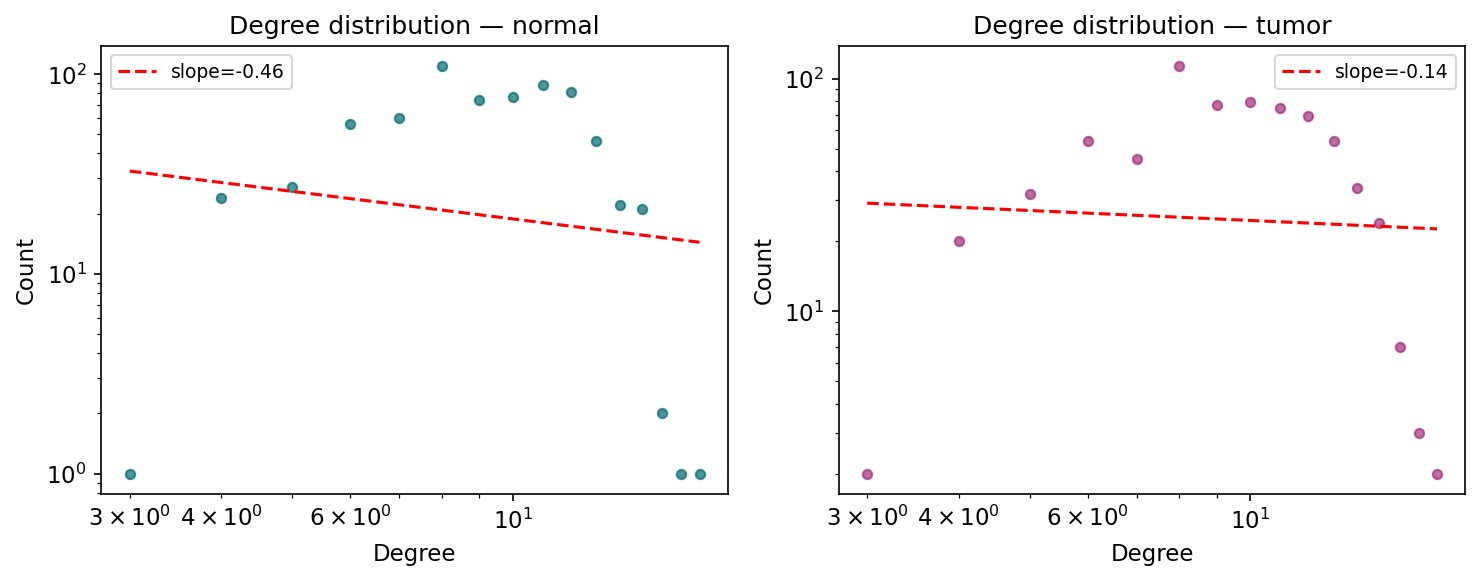

[Fig 1] degree distribution saved


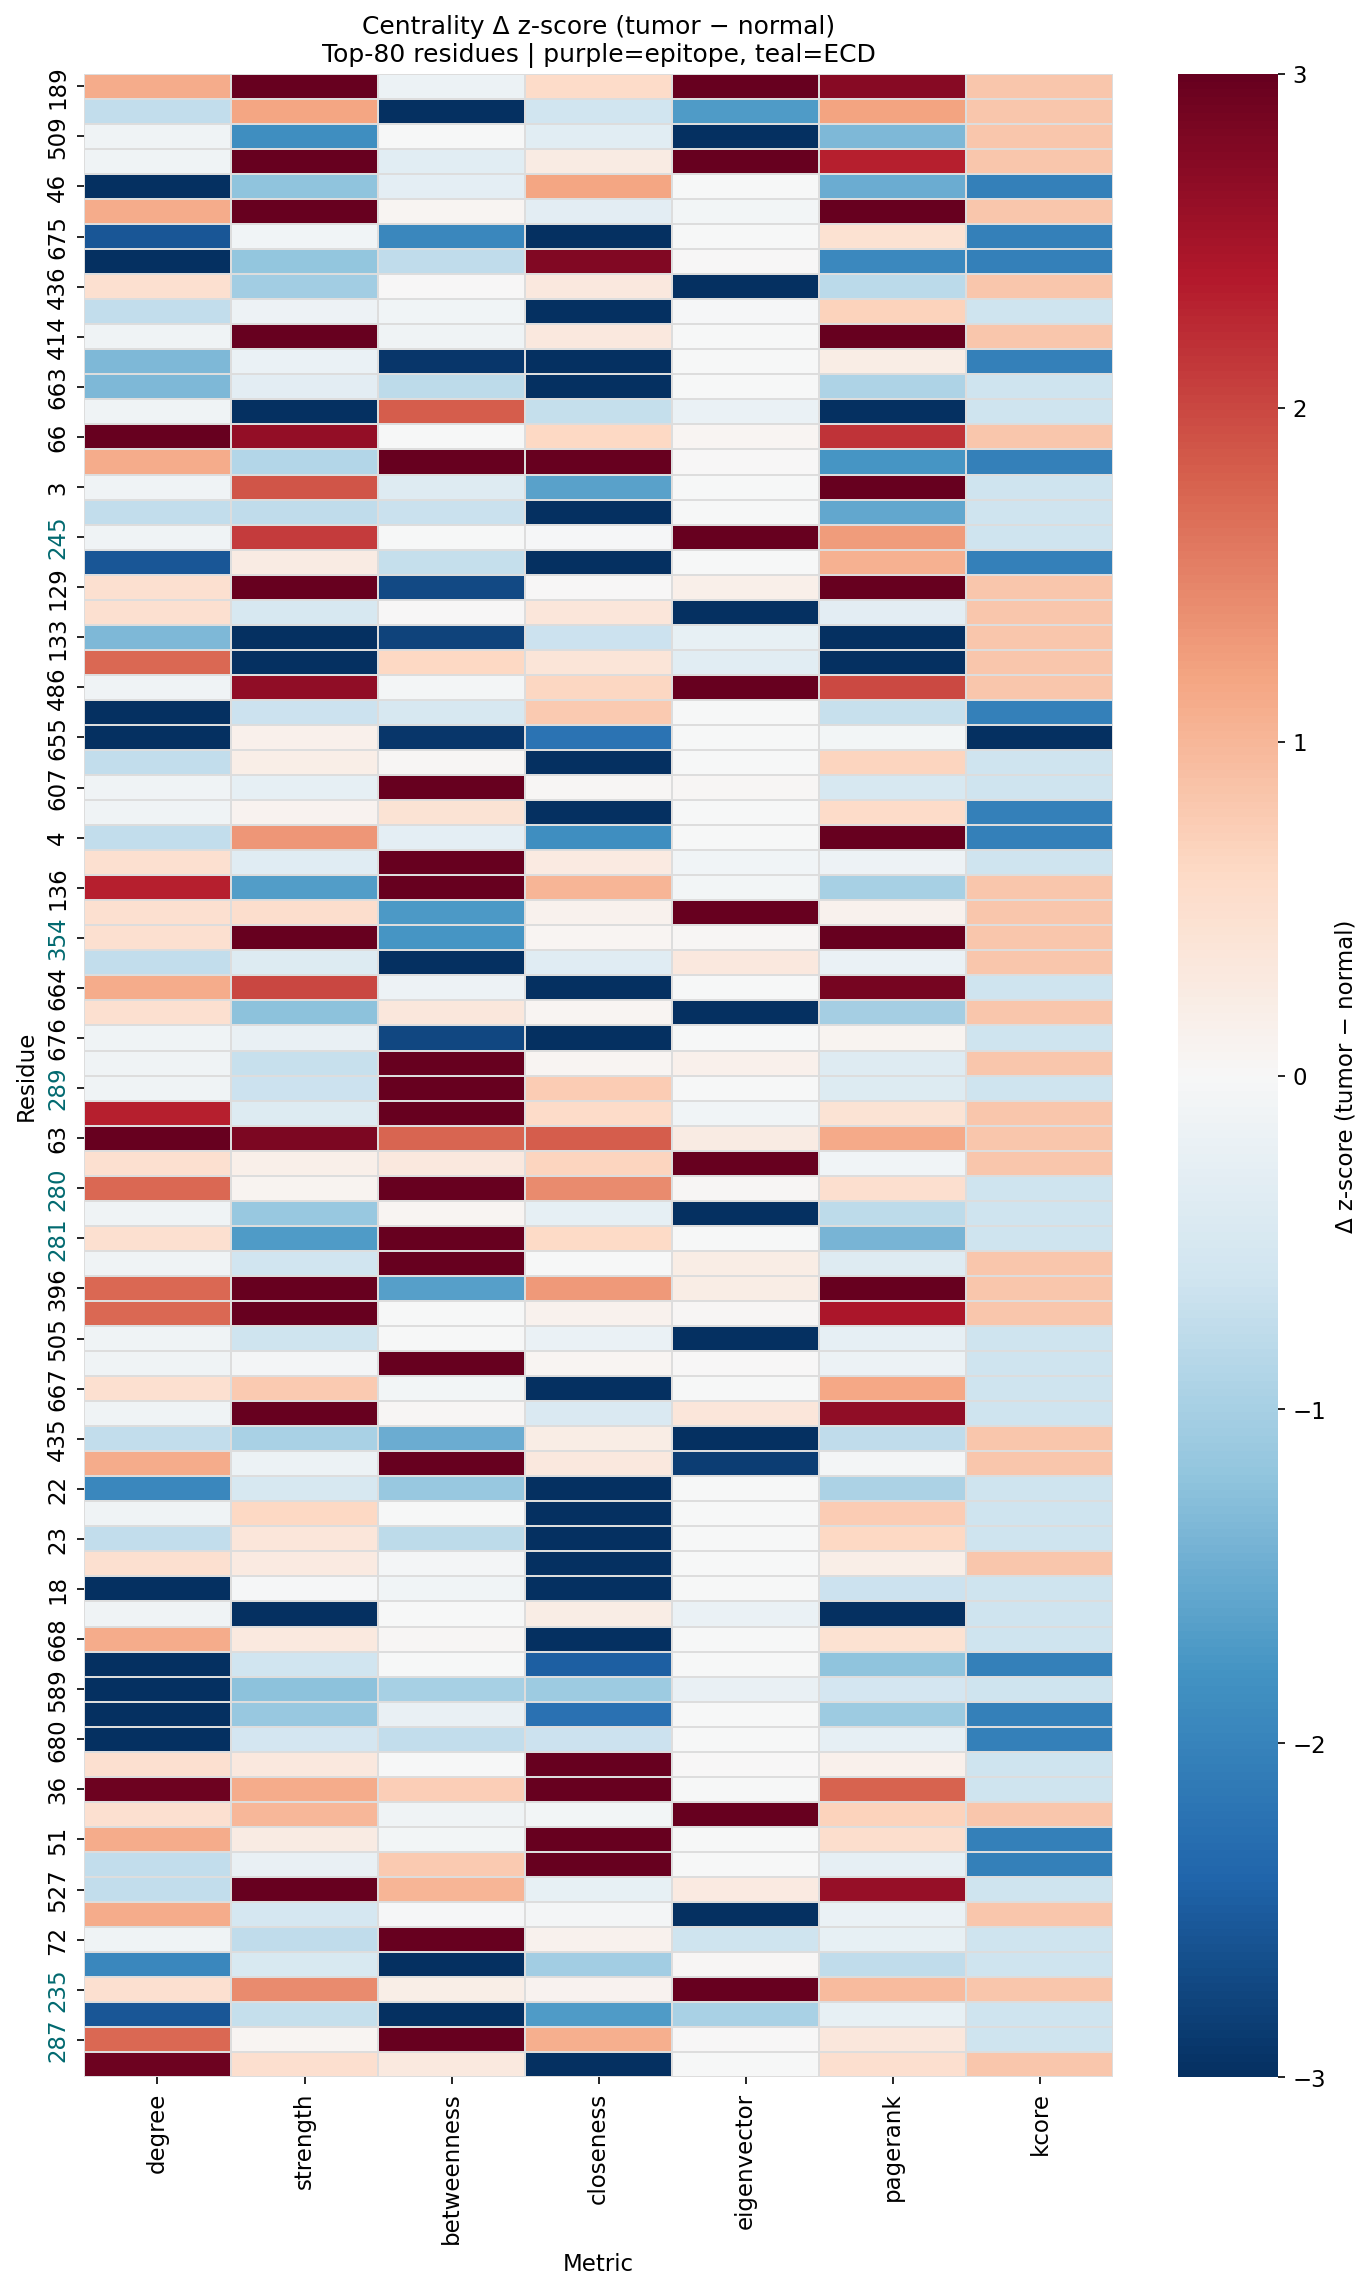

[Fig 2] centrality delta heatmap saved
[Fig 3] columns detected: x=cohens_d, y=FDR, metric=metric
        STAT_DF shape: (28, 13)


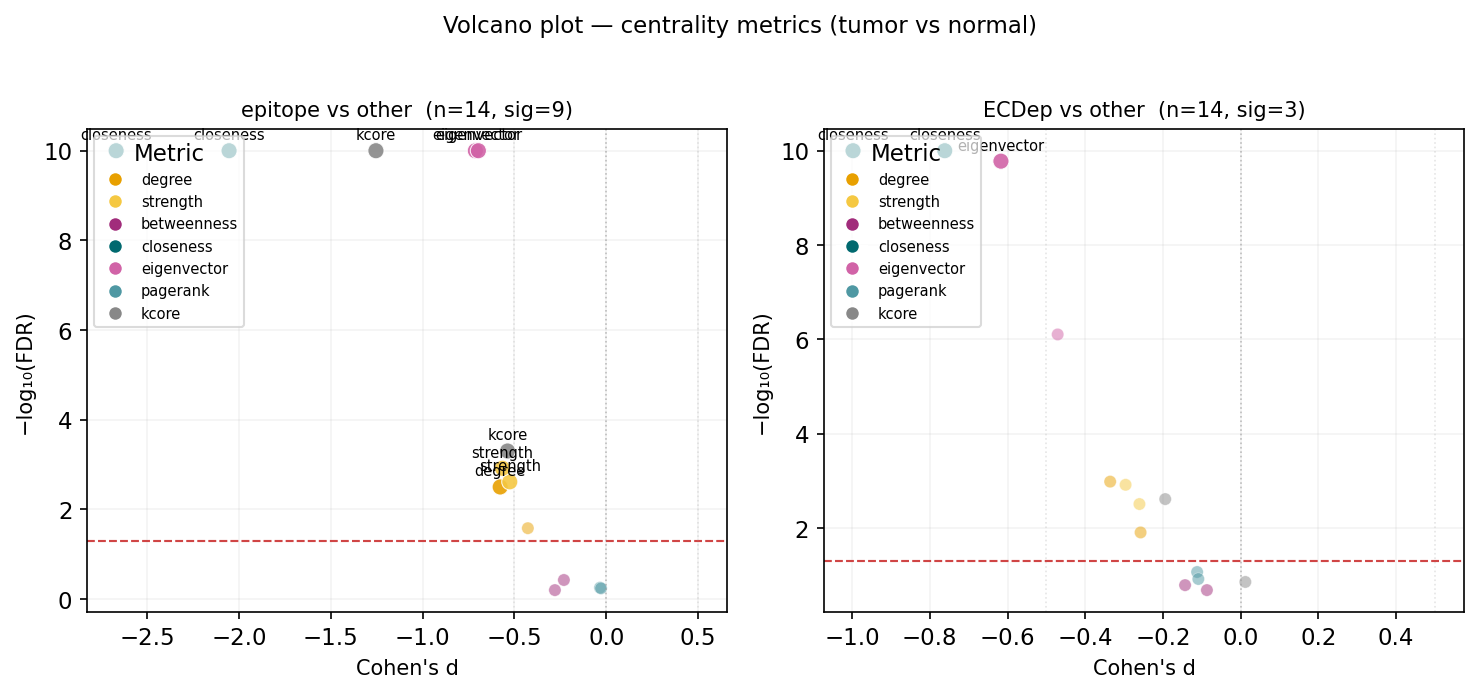

[Fig 3] volcano saved  →  mania_analysis_output/figures/fig3_volcano.png


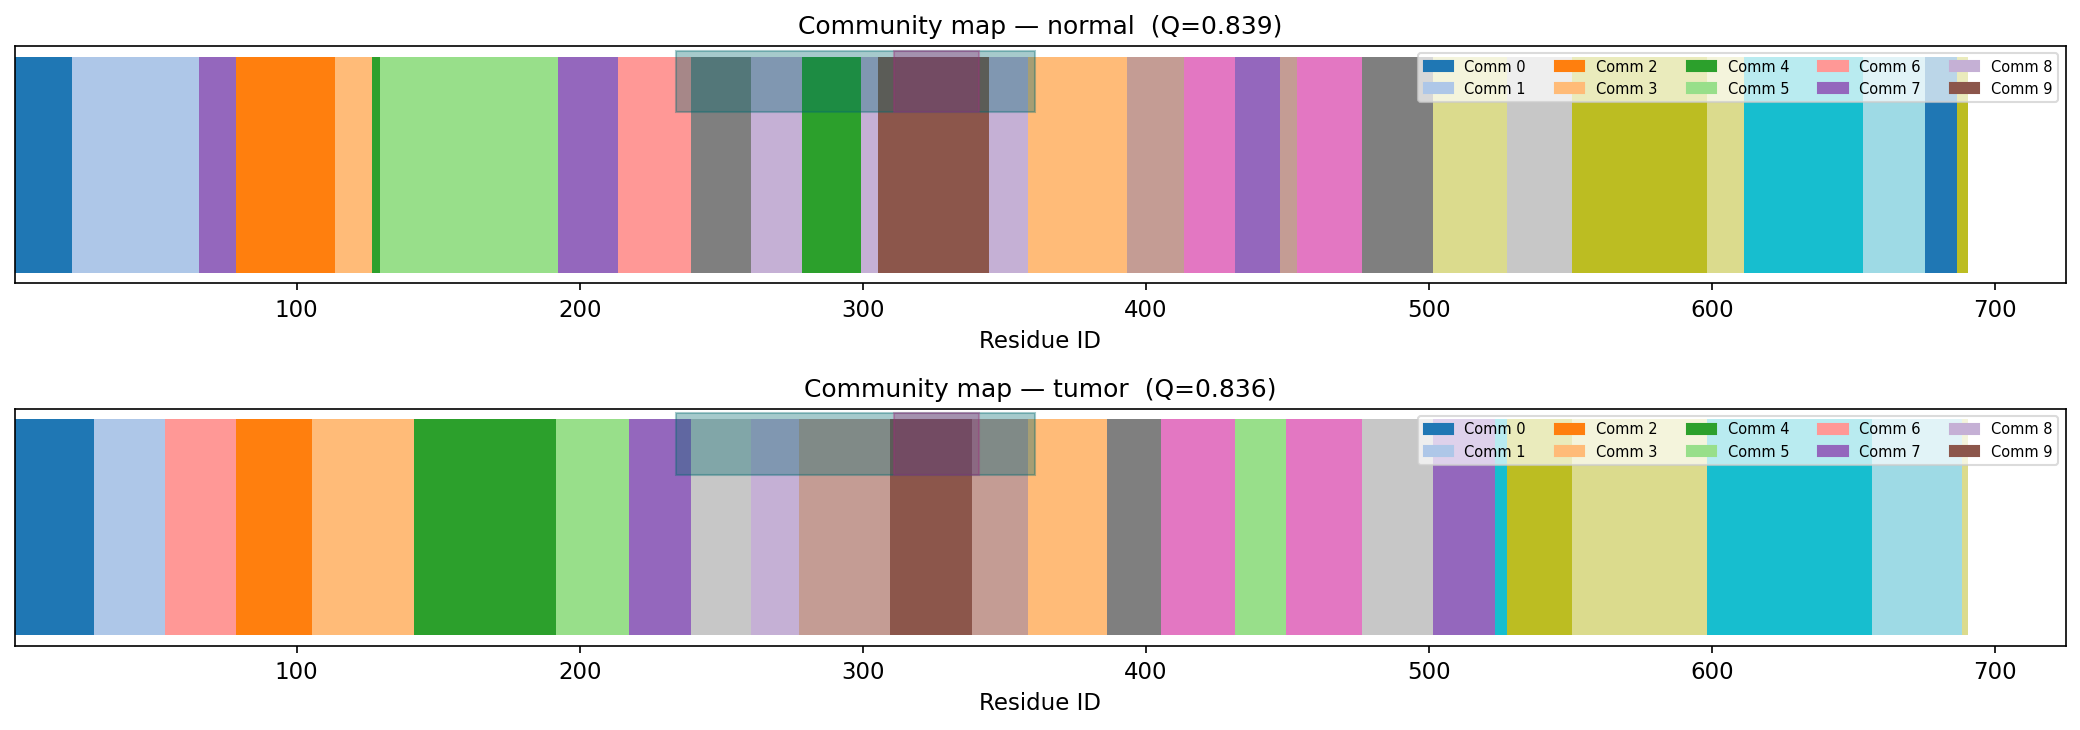

[Fig 4] community linear map saved


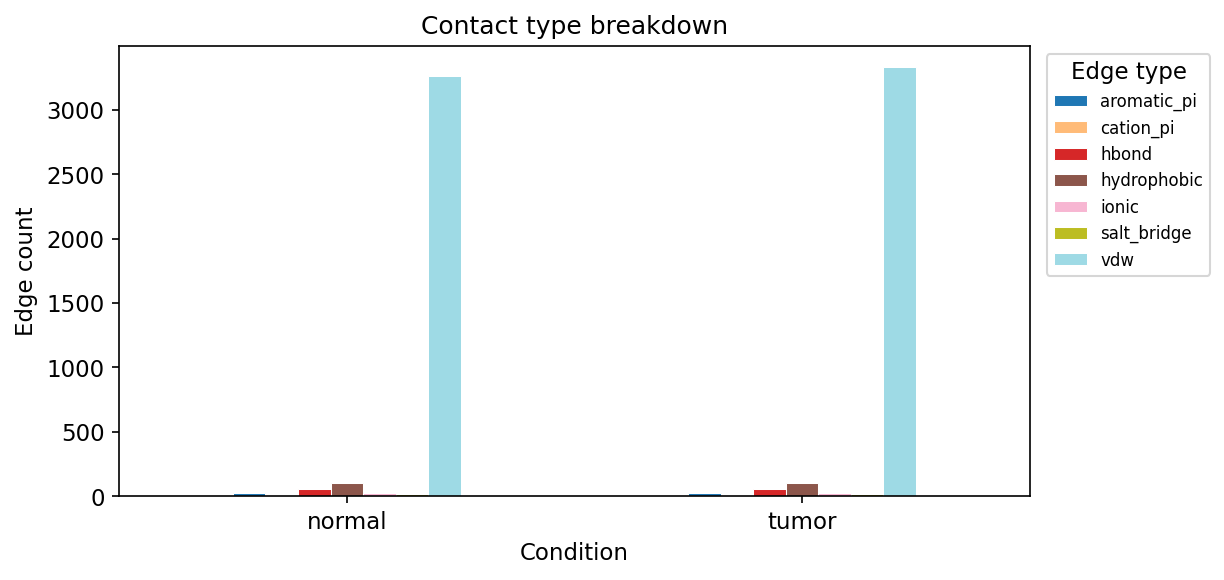

[Fig 5] contact type breakdown saved
[Fig 6] conditions : ['normal', 'tumor']
        metrics    : ['nedges', 'density', 'mean_degree', 'modularity', 'betweenness_mean', 'closeness_mean', 'n_communities']
        x-axis     : frame_start


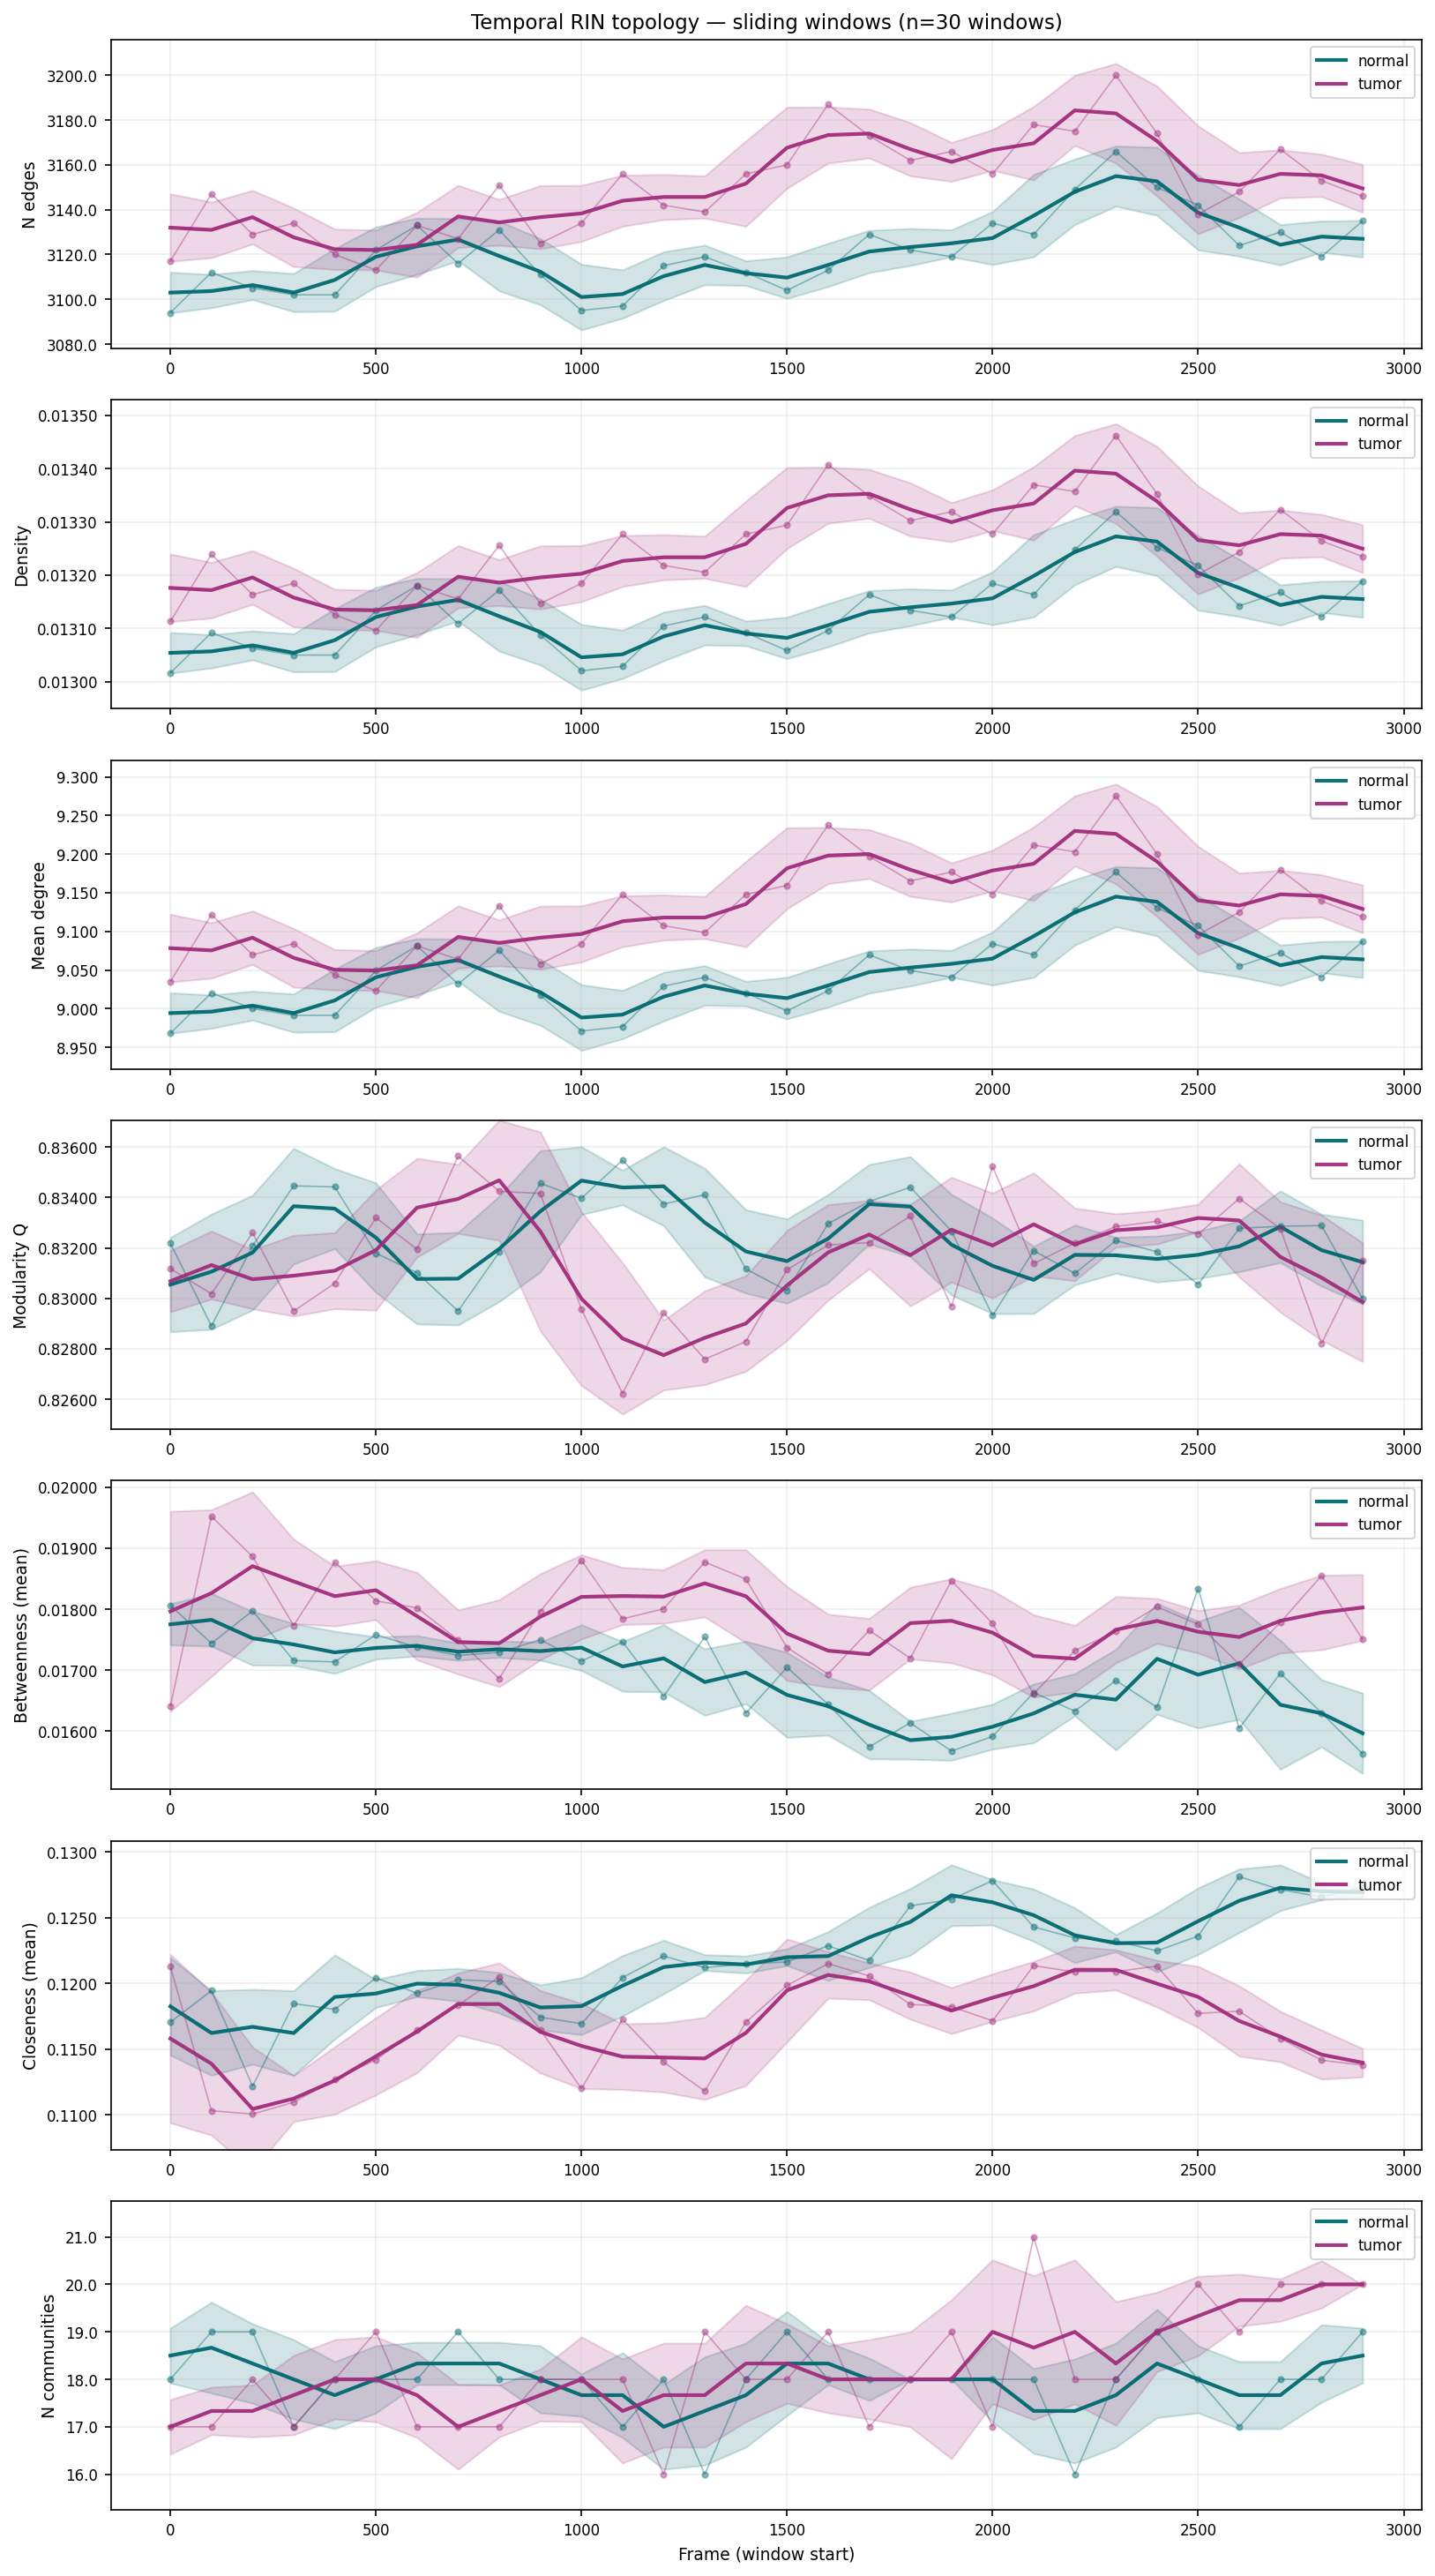

[Fig 6] saved  →  mania_analysis_output/figures/fig6_temporal_rin.png


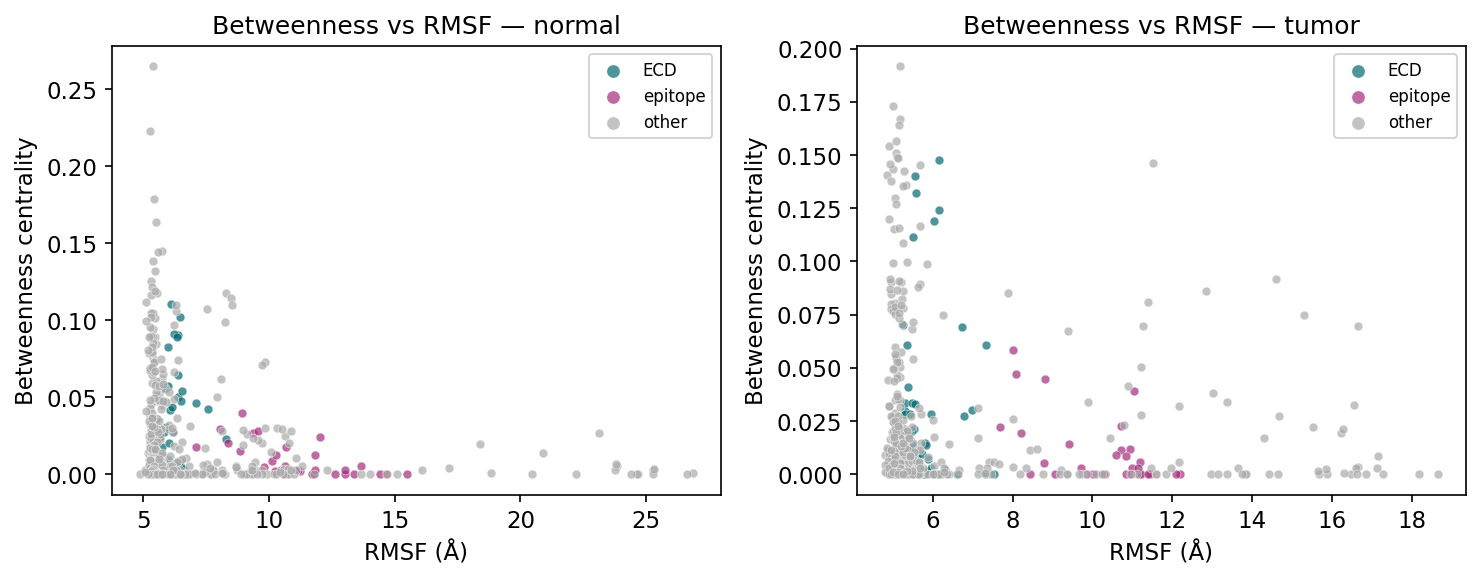

[Fig 7] betweenness vs RMSF scatter saved

✓ All figures saved to: /content/mania_analysis_output/figures
  conformation_clustering_normal.png  (67 KB)
  conformation_clustering_tumor.png  (70 KB)
  conformation_pca_normal.png  (109 KB)
  conformation_pca_tumor.png  (114 KB)
  fig1_degree_distribution.png  (46 KB)
  fig2_centrality_heatmap_delta.png  (133 KB)
  fig3_volcano.png  (93 KB)
  fig4_community_linear.png  (65 KB)
  fig5_contact_type_breakdown.png  (42 KB)
  fig6_temporal_rin.png  (1023 KB)
  fig7_betweenness_vs_rmsf.png  (105 KB)


In [ ]:
# ── MANIA: Visualization cell ─────────────────────────────────────────────────
# Generates 7 figures saved to FIG_DIR.
# Dependencies: CENTRALITY, GRAPHS, EDGES, RESTABLE,
#               STAT_DF, PARTITIONS, TEMPORAL_RESULTS
# cell id: cell-014-figures

import warnings
warnings.filterwarnings('ignore')

FIG_DIR.mkdir(parents=True, exist_ok=True)

COND_COLORS = {'normal': '#01696f', 'tumor': '#a12c7b'}

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1 — Degree distribution (log-log) per condition
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(5 * len(CONDITIONS), 4))
if len(CONDITIONS) == 1:
    axes = [axes]
for ax, cond in zip(axes, CONDITIONS):
    if cond not in GRAPHS:
        continue
    degrees = [d for _, d in GRAPHS[cond].degree()]
    vals, cnts = np.unique(degrees, return_counts=True)
    ax.scatter(vals, cnts, s=20, alpha=0.7, color=COND_COLORS.get(cond, '#555'))
    mask = (vals > 0) & (cnts > 0)
    if mask.sum() >= 2:
        coeffs = np.polyfit(np.log(vals[mask]), np.log(cnts[mask]), 1)
        xf = np.linspace(vals[mask].min(), vals[mask].max(), 100)
        ax.plot(xf, np.exp(np.polyval(coeffs, np.log(xf))),
                'r--', lw=1.5, label=f'slope={coeffs[0]:.2f}')
        ax.legend(fontsize=9)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Degree'); ax.set_ylabel('Count')
    ax.set_title(f'Degree distribution — {cond}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('[Fig 1] degree distribution saved')

# ─────────────────────────────────────────────────────────────────────────────
# Fig 2 — Centrality heatmap Δ(tumor − normal), z-score per metric
# ─────────────────────────────────────────────────────────────────────────────
if all(c in CENTRALITY for c in CONDITIONS) and len(CONDITIONS) == 2:
    cond_a, cond_b = CONDITIONS[0], CONDITIONS[1]
    ca = CENTRALITY[cond_a].set_index('resid')[METRICS]
    cb = CENTRALITY[cond_b].set_index('resid')[METRICS]
    common = ca.index.intersection(cb.index)
    delta = cb.loc[common] - ca.loc[common]
    delta_z = (delta - delta.mean()) / (delta.std() + 1e-9)
    # выбираем топ-80 остатков по max |z| для читаемости
    row_max = delta_z.abs().max(axis=1)
    top_resids = row_max.nlargest(min(80, len(row_max))).index
    delta_plot = delta_z.loc[top_resids]

    fig, ax = plt.subplots(figsize=(len(METRICS) * 1.2 + 1, min(18, len(top_resids) * 0.18 + 1)))
    sns.heatmap(delta_plot, cmap='RdBu_r', center=0, vmin=-3, vmax=3,
                ax=ax, linewidths=0.2, linecolor='#ddd',
                cbar_kws={'label': 'Δ z-score (tumor − normal)'})

    # подсветка регионов: epitope / ECD
    region_map = {}
    for cond in CONDITIONS:
        if cond in RESTABLE:
            for _, row in RESTABLE[cond].iterrows():
                region_map[int(row['resid'])] = row.get('region', 'other')
    for ytick_label in ax.get_yticklabels():
        try:
            resid = int(ytick_label.get_text())
            region = region_map.get(resid, 'other')
            if region == 'epitope':
                ytick_label.set_color('#a12c7b')
                ytick_label.set_fontweight('bold')
            elif region == 'ECD':
                ytick_label.set_color('#01696f')
        except ValueError:
            pass

    ax.set_title(f'Centrality Δ z-score ({cond_b} − {cond_a})\nTop-{len(top_resids)} residues | purple=epitope, teal=ECD')
    ax.set_xlabel('Metric'); ax.set_ylabel('Residue')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig2_centrality_heatmap_delta.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print('[Fig 2] centrality delta heatmap saved')
else:
    print('[Fig 2] skipped — need exactly 2 conditions in CENTRALITY')

# ─────────────────────────────────────────────────────────────────────────────
# Fig 3 — Volcano plot: Cohen's d vs −log10(FDR) per comparison
# ─────────────────────────────────────────────────────────────────────────────
if 'STAT_DF' not in dir() or not isinstance(STAT_DF, pd.DataFrame) or STAT_DF.empty:
    print('[Fig 3] skipped — STAT_DF not found or empty')
else:
    # ── 1. Находим нужные колонки по приоритету ──────────────────────────────
    _x_candidates = ['cohens_d', 'Cohen_d', 'effect_size', 'statistic']
    _y_candidates = ['FDR', 'fdr', 'FDR1', 'pval_fdr', 'pvalue', 'pval', 'U_pval']
    _m_candidates = ['metric', 'feature', 'variable']

    x_col = next((c for c in _x_candidates if c in STAT_DF.columns), None)
    y_col = next((c for c in _y_candidates if c in STAT_DF.columns), None)
    m_col = next((c for c in _m_candidates if c in STAT_DF.columns), None)

    print(f'[Fig 3] columns detected: x={x_col}, y={y_col}, metric={m_col}')
    print(f'        STAT_DF shape: {STAT_DF.shape}')

    if x_col is None or y_col is None:
        print(f'[Fig 3] ERROR — не найдены нужные колонки.\n'
              f'        Доступные: {list(STAT_DF.columns)}')
    else:
        # ── 2. Разбивка по comparison ─────────────────────────────────────────
        comp_col = 'comparison' if 'comparison' in STAT_DF.columns else None
        comparisons = STAT_DF[comp_col].unique() if comp_col else ['all']

        n_comp = len(comparisons)
        fig, axes = plt.subplots(1, n_comp,
                                 figsize=(5 * n_comp, 4.5),
                                 squeeze=False)

        # ── цветовая схема по метрике ─────────────────────────────────────────
        METRIC_COLORS = {
            'betweenness':  '#a12c7b',
            'eigenvector':  '#d163a7',
            'closeness':    '#01696f',
            'pagerank':     '#4f98a3',
            'degree':       '#e8a000',
            'strength':     '#f5c842',
            'kcore':        '#888888',
        }
        DEFAULT_COLOR = '#aaaaaa'

        for ax, comp in zip(axes[0], comparisons):
            sub = STAT_DF[STAT_DF[comp_col] == comp].copy() \
                  if comp_col else STAT_DF.copy()

            # ── 3. Чистим данные ──────────────────────────────────────────────
            sub[x_col] = pd.to_numeric(sub[x_col], errors='coerce')
            sub[y_col] = pd.to_numeric(sub[y_col], errors='coerce')
            sub = sub.dropna(subset=[x_col, y_col])

            if sub.empty:
                ax.set_title(f'{comp}\n(нет данных после dropna)')
                continue

            x = sub[x_col].values.astype(float)
            y = -np.log10(np.clip(sub[y_col].values.astype(float), 1e-10, 1.0))

            # ── 4. Цвета ──────────────────────────────────────────────────────
            if m_col:
                colors = [METRIC_COLORS.get(str(m).lower(), DEFAULT_COLOR)
                          for m in sub[m_col]]
            else:
                colors = [DEFAULT_COLOR] * len(x)

            # ── 5. Категории точек (для zorder) ──────────────────────────────
            sig_mask   = (sub[y_col].values < 0.05) & (np.abs(x) > 0.5)
            insig_mask = ~sig_mask

            ax.scatter(x[insig_mask], y[insig_mask],
                       c=np.array(colors)[insig_mask],
                       s=35, alpha=0.5, edgecolors='white', lw=0.3,
                       zorder=2, label='_nolegend_')
            ax.scatter(x[sig_mask], y[sig_mask],
                       c=np.array(colors)[sig_mask],
                       s=60, alpha=0.9, edgecolors='white', lw=0.5,
                       zorder=3, label='_nolegend_')

            # ── 6. Пороговые линии ────────────────────────────────────────────
            ax.axhline(-np.log10(0.05), ls='--', lw=1.0,
                       color='#cc3333', alpha=0.7, label='FDR = 0.05')
            ax.axvline(0,  ls=':', lw=0.8, color='#999', alpha=0.6)
            ax.axvline( 0.5, ls=':', lw=0.8, color='#ccc', alpha=0.5)
            ax.axvline(-0.5, ls=':', lw=0.8, color='#ccc', alpha=0.5)

            # ── 7. Подписи значимых точек ─────────────────────────────────────
            if m_col:
                for _, row in sub[sig_mask].iterrows():
                    ax.annotate(
                        str(row[m_col]),
                        (row[x_col],
                         -np.log10(max(float(row[y_col]), 1e-10))),
                        fontsize=7, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points',
                    )

            # ── 8. Легенда по метрикам ────────────────────────────────────────
            if m_col:
                present_metrics = sub[m_col].dropna().unique()
                legend_handles = [
                    plt.Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=METRIC_COLORS.get(str(m).lower(),
                                                                  DEFAULT_COLOR),
                               markersize=7, label=str(m))
                    for m in present_metrics
                ]
                ax.legend(handles=legend_handles,
                          title='Metric', fontsize=7,
                          loc='upper left', framealpha=0.7)

            ax.axhline(-np.log10(0.05), ls='--', lw=1.0,
                       color='#cc3333', alpha=0.7)  # повтор для легенды ниже

            n_sig = int(sig_mask.sum())
            ax.set_xlabel("Cohen's d", fontsize=10)
            ax.set_ylabel("−log₁₀(FDR)", fontsize=10)
            ax.set_title(f'{comp}  (n={len(sub)}, sig={n_sig})', fontsize=10)
            ax.grid(alpha=0.15)

        plt.suptitle("Volcano plot — centrality metrics (tumor vs normal)",
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig3_volcano.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close()
        print(f'[Fig 3] volcano saved  →  {FIG_DIR / "fig3_volcano.png"}')

# ─────────────────────────────────────────────────────────────────────────────
# Fig 4 — Community map на линейной схеме белка (условия side-by-side)
# ─────────────────────────────────────────────────────────────────────────────
if PARTITIONS:
    import matplotlib.patches as mpatches
    import matplotlib.cm as cm

    fig, axes = plt.subplots(len(CONDITIONS), 1,
                             figsize=(14, 2.5 * len(CONDITIONS)), squeeze=False)
    for ax, cond in zip(axes[:, 0], CONDITIONS):
        if cond not in PARTITIONS or cond not in RESTABLE:
            ax.set_title(f'{cond} — no data'); continue
        part = PARTITIONS[cond]           # {resid: community_id}
        rt   = RESTABLE[cond].set_index('resid')
        resids = sorted(part.keys())
        comm_ids = sorted(set(part.values()))
        cmap = cm.get_cmap('tab20', max(len(comm_ids), 1))
        color_map = {c: cmap(i) for i, c in enumerate(comm_ids)}

        for resid in resids:
            ax.barh(0, 1, left=resid - 0.5,
                    color=color_map[part[resid]], height=0.6, linewidth=0)

        # регионы: эпитоп и ECD
        region_ranges = {}
        for resid in resids:
            region = rt.loc[resid, 'region'] if resid in rt.index else 'other'
            if region not in ('other', 'full_protein'):
                region_ranges.setdefault(region, []).append(resid)
        for region, rlist in region_ranges.items():
            rmin, rmax = min(rlist), max(rlist)
            color_reg = '#a12c7b' if 'epitope' in region.lower() else '#01696f'
            ax.axvspan(rmin, rmax, ymin=0.72, ymax=0.98,
                       alpha=0.35, color=color_reg, label=region)

        ax.set_yticks([]); ax.set_xlabel('Residue ID')
        ax.set_title(f'Community map — {cond}  (Q={MODULARITY.get(cond, float("nan")):.3f})')
        handles = [mpatches.Patch(color=color_map[c], label=f'Comm {c}') for c in comm_ids[:10]]
        ax.legend(handles=handles, ncol=5, fontsize=7,
                  loc='upper right', framealpha=0.7)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig4_community_linear.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print('[Fig 4] community linear map saved')
else:
    print('[Fig 4] skipped — PARTITIONS empty')

# ─────────────────────────────────────────────────────────────────────────────
# Fig 5 — Contact type breakdown (stacked bar, normal vs tumor)
# ─────────────────────────────────────────────────────────────────────────────
if EDGES:
    edge_type_col = 'edge_type' if 'edge_type' in next(iter(EDGES.values())).columns else None
    if edge_type_col:
        all_types = sorted(set(
            t for df in EDGES.values() for t in df[edge_type_col].unique()))
        counts = {cond: EDGES[cond][edge_type_col].value_counts()
                  for cond in CONDITIONS if cond in EDGES}
        df_bar = pd.DataFrame(counts).fillna(0).loc[
            [t for t in all_types if t in pd.DataFrame(counts).index]]

        fig, ax = plt.subplots(figsize=(max(6, len(all_types) * 0.9 + 2), 4))
        df_bar.T.plot(kind='bar', ax=ax, colormap='tab20', edgecolor='white', lw=0.5)
        ax.set_xlabel('Condition'); ax.set_ylabel('Edge count')
        ax.set_title('Contact type breakdown')
        ax.legend(title='Edge type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
        ax.tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig5_contact_type_breakdown.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close()
        print('[Fig 5] contact type breakdown saved')
    else:
        print('[Fig 5] skipped — no edge_type column in EDGES')
else:
    print('[Fig 5] skipped — EDGES empty')

# ─────────────────────────────────────────────────────────────────────────────
# Fig 6 — Temporal RIN metrics (sliding windows)
# Источник: TEMPORAL_RESULTS (cell-011) или TEMPORAL_RIN
# Метрики: nedges, density, mean_degree, modularity,
#           betweenness_mean, closeness_mean, n_communities
# ─────────────────────────────────────────────────────────────────────────────

# ── алиас ────────────────────────────────────────────────────────────────────
_tdata = TEMPORAL_RESULTS

_tdata = {c: df for c, df in _tdata.items()
          if isinstance(df, pd.DataFrame) and not df.empty}

if not _tdata:
    print('[Fig 6] skipped — нет данных в TEMPORAL_RESULTS / TEMPORAL_RIN')
else:
    _wanted = ['nedges', 'density', 'mean_degree', 'modularity',
               'betweenness_mean', 'closeness_mean', 'n_communities']
    _sample  = next(iter(_tdata.values()))
    available = [m for m in _wanted if m in _sample.columns]

    x_col = next((c for c in ('frame_start', 'frame_mid', 'window_start_frame')
                  if c in _sample.columns), None)

    print(f'[Fig 6] conditions : {list(_tdata.keys())}')
    print(f'        metrics    : {available}')
    print(f'        x-axis     : {x_col}')

    if not available:
        print(f'[Fig 6] skipped — нет нужных колонок. '
              f'Доступные: {list(_sample.columns)}')
    else:
        _METRIC_LABELS = {
            'nedges':           'N edges',
            'density':          'Density',
            'mean_degree':      'Mean degree',
            'modularity':       'Modularity Q',
            'betweenness_mean': 'Betweenness (mean)',
            'closeness_mean':   'Closeness (mean)',
            'n_communities':    'N communities',
        }

        n_metrics = len(available)
        fig, axes = plt.subplots(n_metrics, 1,
                                 figsize=(11, 2.8 * n_metrics),
                                 squeeze=False)

        for ax, metric in zip(axes[:, 0], available):

            # ── собираем все значения метрики для автомасштаба Y ─────────────
            _all_vals = []
            for cond in CONDITIONS:
                if cond not in _tdata:
                    continue
                _v = pd.to_numeric(
                    _tdata[cond].get(metric, pd.Series(dtype=float)),
                    errors='coerce').dropna()
                _all_vals.extend(_v.tolist())

            # ── рисуем линии ──────────────────────────────────────────────────
            for cond in CONDITIONS:
                if cond not in _tdata:
                    continue
                df_t  = _tdata[cond]
                if metric not in df_t.columns:
                    continue

                vals  = pd.to_numeric(df_t[metric], errors='coerce')
                x     = (pd.to_numeric(df_t[x_col], errors='coerce')
                         if x_col else pd.Series(range(len(df_t))))
                vals_smooth = vals.rolling(3, center=True, min_periods=1).mean()

                color = COND_COLORS.get(cond, '#555')
                vals_std = vals.rolling(5, center=True, min_periods=1).std().fillna(0)
                ax.fill_between(x, vals_smooth - vals_std, vals_smooth + vals_std,
                alpha=0.18, color=color)
                ax.plot(x, vals,         lw=0.8, alpha=0.4, color=color,
                        marker='o', markersize=3)
                ax.plot(x, vals_smooth,  lw=2.0, alpha=0.95, color=color,
                        label=cond)

            # ── автомасштаб Y: только реальный диапазон + отступ ─────────────
            if _all_vals:
                _vmin, _vmax = min(_all_vals), max(_all_vals)
                _spread = _vmax - _vmin
                if _spread < 1e-10:
                    _pad = abs(_vmax) * 0.10 or 0.01
                else:
                    _pad = _spread * 0.15
                ax.set_ylim(_vmin - _pad, _vmax + _pad)

                # форматирование делений Y под диапазон
                import matplotlib.ticker as mticker
                if _spread > 0 and _spread < 0.01:
                    ax.yaxis.set_major_formatter(
                        mticker.FormatStrFormatter('%.5f'))
                elif _spread > 0 and _spread < 0.1:
                    ax.yaxis.set_major_formatter(
                        mticker.FormatStrFormatter('%.4f'))
                elif _spread > 0 and _spread < 1:
                    ax.yaxis.set_major_formatter(
                        mticker.FormatStrFormatter('%.3f'))
                else:
                    ax.yaxis.set_major_formatter(
                        mticker.FormatStrFormatter('%.1f'))

            ax.set_ylabel(_METRIC_LABELS.get(metric, metric), fontsize=9)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=8)

        x_label = ('Frame (window start)'
                   if x_col and 'frame' in x_col else 'Window index')
        n_win = len(next(iter(_tdata.values())))
        axes[-1, 0].set_xlabel(x_label, fontsize=9)
        axes[0,  0].set_title(
            f'Temporal RIN topology — sliding windows (n={n_win} windows)',
            fontsize=11)

        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig6_temporal_rin.png', dpi=150,
                    bbox_inches='tight')
        plt.show(); plt.close()
        print(f'[Fig 6] saved  →  {FIG_DIR / "fig6_temporal_rin.png"}')

# ─────────────────────────────────────────────────────────────────────────────
# Fig 7 — Betweenness vs RMSF scatter (color = region)
# ─────────────────────────────────────────────────────────────────────────────
region_palette = {
    'epitope':     '#a12c7b',
    'ECD':         '#01696f',
    'other':       '#aaaaaa',
}
plotted_any = False
fig, axes = plt.subplots(1, len(CONDITIONS),
                         figsize=(5 * len(CONDITIONS), 4), squeeze=False)
for ax, cond in zip(axes[0], CONDITIONS):
    if cond not in CENTRALITY or cond not in RESTABLE:
        ax.set_title(f'{cond} — no data'); continue
    cent = CENTRALITY[cond].set_index('resid')
    rt   = RESTABLE[cond].set_index('resid')
    common = cent.index.intersection(rt.index)
    if 'rmsf_A' not in rt.columns or 'betweenness' not in cent.columns:
        ax.set_title(f'{cond} — rmsf_A or betweenness missing'); continue
    x = rt.loc[common, 'rmsf_A'].astype(float)
    y = cent.loc[common, 'betweenness'].astype(float)
    regions = rt.loc[common, 'region'].fillna('other') if 'region' in rt.columns \
              else pd.Series('other', index=common)
    for region, grp in regions.groupby(regions):
        c = region_palette.get(region, '#ccc')
        ax.scatter(x[grp.index], y[grp.index],
                   s=18, alpha=0.7, color=c,
                   label=region, edgecolors='white', lw=0.3)
    ax.set_xlabel('RMSF (Å)'); ax.set_ylabel('Betweenness centrality')
    ax.set_title(f'Betweenness vs RMSF — {cond}')
    ax.legend(fontsize=8, markerscale=1.5)
    plotted_any = True

if plotted_any:
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig7_betweenness_vs_rmsf.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print('[Fig 7] betweenness vs RMSF scatter saved')
else:
    plt.close()
    print('[Fig 7] skipped — required columns not found')

# ─────────────────────────────────────────────────────────────────────────────
print(f'\n✓ All figures saved to: {FIG_DIR.resolve()}')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.0f} KB)')

## Cell 12b — Выгрузка результатов на Яндекс.Диск

Загружает все файлы из `OUT_DIR` в `YADISK_OUTPUT_PATH`.  
При `SOURCE_ARTEFACTS='local'` ячейку можно пропустить (выгрузка всё равно доступна).


In [ ]:
# MANIA: module io -> YaDiskLoader.upload_artefacts()
# Package file: mania/io/yadisk_loader.py
#
# Выгружает артефакты MANIA_analysis на Яндекс.Диск в YADISK_OUTPUT_PATH.
# Запускай вручную после завершения всего пайплайна.

def _yadisk_upload_file(client, local_path, remote_path):
    """Загрузить один файл на Я.Диск (overwrite)."""
    t0 = time.time()
    client.upload(str(local_path), remote_path, overwrite=True)
    size_mb = local_path.stat().st_size / 1024**2
    print(f'  [ok]    {local_path.name}  ({size_mb:.1f} MB, {time.time()-t0:.1f}s)')

def upload_analysis_artefacts(token, remote_dir, local_dir):
    """Выгрузить все файлы из local_dir -> remote_dir на Я.Диске."""
    import yadisk
    files_to_upload = sorted(p for p in local_dir.iterdir()
                             if p.is_file() and p.suffix in {'.csv', '.json', '.png'})
    if not files_to_upload:
        print(f"Нет файлов для выгрузки в {local_dir}")
        return

    with yadisk.Client(token=token) as client:
        if not client.check_token():
            raise ValueError("Токен Яндекс.Диска невалиден.")
        # Создать папку на Диске (рекурсивно)
        parts = remote_dir.replace('disk:/', '').split('/')
        current = 'disk:/'
        for part in parts:
            if not part:
                continue
            current = f"{current.rstrip('/')}/{part}"
            try:
                client.mkdir(current)
            except Exception:
                pass  # уже существует

        print(f"Выгрузка {len(files_to_upload)} файлов → {remote_dir}")
        for local_path in files_to_upload:
            remote_path = f"{remote_dir.rstrip('/')}/{local_path.name}"
            _yadisk_upload_file(client, local_path, remote_path)

    print(f"Выгрузка завершена → {remote_dir}")

# ── Выполнение: выгрузка CSV/JSON + фигур раздельно ──────────────────────────
try:
    _token = _resolve_yadisk_token()

    # 1. CSV / JSON → analysis_exports/
    upload_analysis_artefacts(_token, YADISK_OUTPUT_PATH, OUT_DIR)

    # 2. PNG-фигуры → analysis_exports/figures/
    _fig_remote = YADISK_OUTPUT_PATH.rstrip('/') + '/figures'
    if FIG_DIR.exists() and any(FIG_DIR.glob('*.png')):
        upload_analysis_artefacts(_token, _fig_remote, FIG_DIR)
    else:
        print(f'[skip] FIG_DIR пуст или не существует: {FIG_DIR}')

except Exception as _e:
    print(f'[skip] Выгрузка на Я.Диск пропущена: {_e}')
    print('  Убедись, что MW_TOKEN задан и YADISK_OUTPUT_PATH корректен.')

Выгрузка 16 файлов → disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/30ns_03-2026/results/analysis_export_v1.2
  [ok]    centrality_normal.csv  (0.1 MB, 2.8s)
  [ok]    centrality_tumor.csv  (0.1 MB, 2.3s)
  [ok]    communities_normal.csv  (0.0 MB, 1.3s)
  [ok]    communities_tumor.csv  (0.0 MB, 1.6s)
  [ok]    comparison.csv  (0.0 MB, 1.7s)
  [ok]    conformation_labels_normal.csv  (0.0 MB, 1.6s)
  [ok]    conformation_labels_tumor.csv  (0.0 MB, 1.4s)
  [ok]    conformation_pca_normal.csv  (0.0 MB, 2.0s)
  [ok]    conformation_pca_tumor.csv  (0.0 MB, 2.0s)
  [ok]    graph.json  (1.3 MB, 3.0s)
  [ok]    manifest.json  (0.0 MB, 1.4s)
  [ok]    metrics_normal.csv  (0.1 MB, 2.2s)
  [ok]    metrics_tumor.csv  (0.1 MB, 1.6s)
  [ok]    stats.csv  (0.0 MB, 1.6s)
  [ok]    temporal_rin_normal.csv  (0.0 MB, 1.8s)
  [ok]    temporal_rin_tumor.csv  (0.0 MB, 1.5s)
Выгрузка завершена → disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/30ns_03-2026/results/analysis_export_v1.2
Выгруз